# 0. Analysis Framework

본 분석은 학습자의 이탈을 단일 기준이 아닌,
Stage(학습 단계)와 Duration(시간)이라는 두 가지 축에서 분리하여 분석하는 것을 목표로 한다.

Stage는 학습자가 어느 단계에서 이탈했는지를 나타내며,
Duration은 해당 단계 내에서 언제 이탈이 발생했는지를 설명한다.

특히, Stage는 구조적 전환(Registered → Viewed → Explored → Sufficient)을 기준으로 정의되며,
Duration은 초기 이탈 여부를 판단하기 위한 기준 변수로 활용된다.

Stage와 Duration은 서로 다른 성격의 분석 축으로,
본 분석에서는 두 기준을 혼합하지 않고 독립적으로 해석한다.

이를 통해 이탈의 위치(Where)와 시점(When)을 각각 명확하게 파악할 수 있도록 한다.

## Analysis Procedure

각 Stage별 분석은 다음 절차에 따라 수행한다.

1. 해당 Stage에서 이탈한 집단과 유지된 집단을 정의한다.  
2. 각 활동 지표에 대해 집단 간 차이를 통계적으로 검정한다.  
3. 효과크기를 함께 제시하여 실질적인 차이의 크기를 평가한다.  
4. 유의한 변수에 대해 threshold를 탐색한다.  
5. 도출된 threshold가 실제로 집단을 구분하는지 재검증한다.

# 1. Data Load

본 단계에서는 분석에 필요한 데이터를 불러온다.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import platform
from datetime import datetime
from matplotlib.ticker import PercentFormatter

# ── 운영체제별 한글 폰트 설정 ──
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':  # macOS
    plt.rcParams['font.family'] = 'AppleGothic'
else:  # Linux
    plt.rcParams['font.family'] = 'NanumGothic'

# 마이너스 기호 깨짐 방지
plt.rcParams['axes.unicode_minus'] = False


from scipy.stats import chi2_contingency, mannwhitneyu
from scipy.stats.contingency import association

df = pd.read_csv("course_final.csv", encoding="utf-8", index_col=0)

df.info()
df.head()

<class 'pandas.DataFrame'>
Index: 533993 entries, HarvardX/PH207x/2012_Fall to MITx/6.00x/2013_Spring
Data columns (total 30 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   userid_DI             533993 non-null  str    
 1   registered            533993 non-null  int64  
 2   viewed                533993 non-null  int64  
 3   explored              533993 non-null  int64  
 4   certified             533993 non-null  int64  
 5   final_cc_cname_DI     533993 non-null  str    
 6   LoE_DI                533993 non-null  str    
 7   YoB                   452939 non-null  float64
 8   gender                533993 non-null  str    
 9   grade                 483483 non-null  float64
 10  start_time_DI         533993 non-null  str    
 11  last_event_DI         533993 non-null  str    
 12  nevents               532186 non-null  float64
 13  ndays_act             532186 non-null  float64
 14  nplay_video           348922

,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,grade,...,start_year,age_raw,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num
course_id,,,,,,,,,,,,,,,,,,,,,
HarvardX/PH207x/2012_Fall,MHxPC130275857,1,1,1,0,United States,unknown,NaN,unknown,0.0,...,2012,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/CB22x/2013_Spring,MHxPC130539455,1,1,0,0,France,unknown,NaN,unknown,0.0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/CB22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0.0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/ER22x/2013_Spring,MHxPC130088379,1,1,0,0,United States,unknown,NaN,unknown,0.0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN
HarvardX/ER22x/2013_Spring,MHxPC130198098,1,1,0,0,United States,unknown,NaN,unknown,0.0,...,2013,NaN,True,False,NaN,NaN,NaN,unknown,1,NaN


# 2. Stage Definition

## 2.1 Understanding Explored through Behavioral Thresholds

explored 변수는 학습자가 일정 수준 이상으로 강의를 탐색한 상태를 의미하며,
일반적으로 courseware의 약 50% 이상에 접근한 경우로 해석된다.

본 데이터셋에서는 explored가 이미 이진 변수 형태로 제공되므로,
이를 재정의하지 않고 기준 변수로 활용한다.

본 분석에서는 explored를 설명하기 위해,
행동 변수(nevents, ndays_act, nplay_video 등)와의 관계를 분석하고,
어느 수준의 행동이 observed될 때 explored 상태에 도달하는지를 확인한다.

이를 통해 explored를 “대체”하는 것이 아니라,
explored에 도달하기 위한 행동 기준(threshold)을 도출하는 것을 목표로 한다.

## 2.2 Defining Sufficient

본 분석에서는 학습의 최종 단계를 단순한 인증(certified)이 아닌,
학습 행동을 기반으로 한 충분한 학습 상태(sufficient)로 정의하였다.

이를 위해 explored == 1이면서 certified == 1인 학습자를 기준 집단으로 설정하고,
각 강의별 nchapters 분포에서 75th percentile을 계산하였다.

이후 해당 기준 이상으로 학습한 경우를 sufficient 상태로 정의하였다.

이 기준은 explored가 학습 시작을 의미한다는 점에서,
그 이후의 학습 깊이를 구분하기 위한 상대적 기준으로 설정되었다.

In [3]:
# 1. 정상 학습 기반 집단 정의
certified_clean = df[
    (df["certified"] == 1) &
    (df["explored"] == 1)
]

# 2. 강의별 nchapters 75% 지점 계산
p75_by_course = (
    certified_clean
    .groupby("course_id")["nchapters"]
    .quantile(0.75)
    .reset_index()
    .rename(columns={"nchapters": "nchapters_p75"})
)

# 3. merge
df = df.merge(p75_by_course, on="course_id", how="left")

# 4. sufficient 생성
df["sufficient"] = (
    (df["nchapters"] >= df["nchapters_p75"]) &
    (df["explored"] == 1)
).astype(int)

In [4]:
# 체크
df[(df["sufficient"] == 1) & (df["explored"] == 0)]

,course_id,userid_DI,registered,viewed,explored,certified,final_cc_cname_DI,LoE_DI,YoB,gender,...,age_missing_original,age_invalid,age_cleaned,age_final,age,age_group,exam_flag,LoE_num,nchapters_p75,sufficient


In [5]:
df["explored"].value_counts(dropna=False)
df["explored"].value_counts(normalize=True, dropna=False)

explored
0    0.929617
1    0.070383
Name: proportion, dtype: float64

다만 sufficient는 nchapters 기반으로 정의된 파생 상태 변수이므로,
이후 단계 분석에서는 nchapters를 설명 변수로 다시 사용하지 않고
독립적인 활동 지표를 중심으로 해석한다.

# 3. Funnel Overview

본 절에서는 학습자의 전체 진행 흐름을 퍼널 구조로 요약한다.

퍼널 단계는 다음과 같이 정의된다:

- Registered: 강의 등록
- Viewed: 강의 접근
- Explored: 학습 시작
- Sufficient: 충분한 학습 수행

각 단계별 학습자 수와 전환 비율을 통해  
학습자의 전반적인 흐름을 파악하고,  

어느 구간에서 이탈이 크게 발생하는지를  
탐색적으로 확인하는 것을 목적으로 한다.

단, 본 절에서는 단순 분포 확인에 초점을 두며,  
통계적 검정이나 threshold 분석은 이후 단계에서 수행한다.

In [6]:
n_registered = df["registered"].sum()
n_viewed = df["viewed"].sum()
n_explored = df["explored"].sum()
n_sufficient = df["sufficient"].sum()

print("Registered:", n_registered)
print("Viewed:", n_viewed)
print("Explored:", n_explored)
print("Sufficient:", n_sufficient)

Registered: 533993
Viewed: 325361
Explored: 37584
Sufficient: 11870


In [7]:
view_rate = n_viewed / n_registered
explore_rate = n_explored / n_viewed
sufficient_rate = n_sufficient / n_explored

print("View Rate:", round(view_rate, 4))
print("Explore Rate:", round(explore_rate, 4))
print("Sufficient Rate:", round(sufficient_rate, 4))

View Rate: 0.6093
Explore Rate: 0.1155
Sufficient Rate: 0.3158


In [8]:
funnel_df = pd.DataFrame({
    "Stage": ["Registered", "Viewed", "Explored", "Sufficient"],
    "Count": [n_registered, n_viewed, n_explored, n_sufficient]
})

funnel_df["Conversion Rate"] = funnel_df["Count"] / funnel_df["Count"].shift(1)
funnel_df.loc[0, "Conversion Rate"] = 1.0

funnel_df

,Stage,Count,Conversion Rate
0,Registered,533993,1.000000
1,Viewed,325361,0.609298
2,Explored,37584,0.115515
3,Sufficient,11870,0.315826


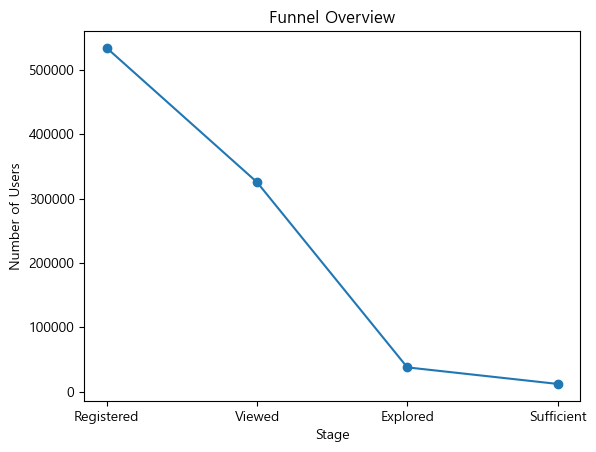

In [9]:
plt.figure()
plt.plot(funnel_df["Stage"], funnel_df["Count"], marker="o")
plt.title("Funnel Overview")
plt.xlabel("Stage")
plt.ylabel("Number of Users")
plt.show()

## Funnel Sanity Check

퍼널 구조가 논리적으로 유지되는지 확인한다.

예를 들어 explored는 viewed 이후 단계로 해석되므로,  
viewed == 0 이면서 explored == 1 인 경우가 많다면  
퍼널을 순차 구조로 해석하는 데 주의가 필요하다.

이 단계에서는 이러한 예외 케이스의 존재 여부를 확인하고,  
이후 분석에서 퍼널을 어떻게 해석할 것인지에 대한 기준을 점검한다.

In [10]:
# explored인데 viewed 안한 경우
invalid_explored = df[
    (df["explored"] == 1) &
    (df["viewed"] != 1)
]

print("Explored without Viewed:", len(invalid_explored))

Explored without Viewed: 0


In [11]:
# sufficient인데 explored 안한 경우
invalid_sufficient = df[
    (df["sufficient"] == 1) &
    (df["explored"] != 1)
]

print("Sufficient without Explored:", len(invalid_sufficient))

Sufficient without Explored: 0


Funnel Overview 결과,  
Registered → Viewed → Explored → Sufficient로 이어지는 과정에서  
단계가 진행될수록 학습자 수가 감소하는 전형적인 퍼널 구조를 확인할 수 있었다.

특히 Viewed → Explored 구간에서 상대적으로 큰 이탈이 발생하는 것으로 나타났으며,  
이는 학습자가 강의에 접근한 이후 실제 학습을 시작하지 않는 경우가 많음을 시사한다.

# 4. Access Stage Analysis (Registered → Viewed)

본 단계에서는 학습자가 강의에 실제로 접근하지 못하는 경우를 분석한다.

Registered → Viewed 전환이 이루어지지 않은 경우를  
“학습 접근 실패”로 정의하며,  

이는 학습 행동이 시작되기 이전 단계에서의 이탈을 의미한다.

본 단계에서는 접근 여부(viewed)를 기준으로  
집단을 구분하고,  

인구통계적 변수 및 기본 특성을 중심으로  
집단 간 차이를 분석한다.

또한 본 단계는 학습 행동 이전 단계이므로,  
행동 지표 기반 threshold 분석은 수행하지 않는다.

In [12]:
access_success = df[df["viewed"] == 1]
access_fail = df[df["viewed"] == 0]

print("Success:", len(access_success))
print("Fail:", len(access_fail))

Success: 325361
Fail: 208632


In [13]:
cat_vars = ["gender", "LoE_DI", "final_cc_cname_DI", "age_group"]

results_cat = []

for var in cat_vars:
    cont = pd.crosstab(df[var], df["viewed"])
    
    chi2, p, _, _ = chi2_contingency(cont)
    
    n = cont.values.sum()
    phi2 = chi2 / n
    r, k = cont.shape
    
    cramers_v = np.sqrt(phi2 / min(r - 1, k - 1))
    
    results_cat.append({
        "variable": var,
        "p_value": p,
        "cramers_v": cramers_v
    })

pd.DataFrame(results_cat)

,variable,p_value,cramers_v
0,gender,0.0,0.081832
1,LoE_DI,0.0,0.066237
2,final_cc_cname_DI,0.0,0.375212
3,age_group,0.0,0.076472


In [14]:
def rank_biserial_from_u(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

num_vars = ["age_final"]

results_num = []

for var in num_vars:
    x = access_success[var].dropna()
    y = access_fail[var].dropna()
    
    u_stat, p = mannwhitneyu(x, y, alternative="two-sided")
    rbc = rank_biserial_from_u(u_stat, len(x), len(y))
    
    results_num.append({
        "variable": var,
        "p_value": p,
        "rank_biserial": rbc,
        "median_success": x.median(),
        "median_fail": y.median()
    })

pd.DataFrame(results_num)

,variable,p_value,rank_biserial,median_success,median_fail
0,age_final,5.252884e-83,0.033686,25.0,25.0


In [15]:
cont = pd.crosstab(df["final_cc_cname_DI"], df["viewed"])
chi2, p, dof, expected = chi2_contingency(cont)
(expected < 5).sum()

np.int64(0)

### Interpretation

Access Stage 분석 결과,  
모든 변수에서 통계적으로 유의한 차이가 확인되었다 (p-value ≈ 0).

그러나 효과크기를 기준으로 해석하면 다음과 같은 특징이 나타난다.

먼저 gender와 LoE_DI의 경우,  
Cramer's V가 각각 0.0818, 0.0662로 매우 낮은 수준을 보이며,  
접근 여부(viewed)에 미치는 영향은 실질적으로 매우 작다고 판단된다.

age 또한 Mann-Whitney U 검정에서는 유의하게 나타났으나,  
rank-biserial 값이 0.0337로 매우 작고,  
두 집단의 중앙값 역시 동일하게 나타나  
실질적인 차이는 거의 없는 것으로 해석된다.

반면 final_cc_cname_DI (국가)의 경우,  
Cramer's V가 0.375 수준으로 상대적으로 큰 효과크기를 보이며,  
접근 여부와 의미 있는 연관성을 가지는 변수로 확인되었다.

## 추가 분석 파트
### 국가별 조회(View) 여부와의 연관성 분석 (Chi-square & Residual Analysis)

학습자의 국가(final_cc_cname_DI)가 강의 조회 여부(viewed)에 영향을 미치는지 확인

카이제곱 검정

국가별로 조회 여부(viewed=0, viewed=1)의 분포가 동일한지 검정하였다.

귀무가설 (H₀):
- 국가와 조회 여부는 독립이다 (국가에 따라 조회 확률이 동일하다)

대립가설 (H₁):
- 국가와 조회 여부는 독립이 아니다 (국가에 따라 조회 확률이 다르다)

In [16]:
# Contingency table: country x viewed
ct = pd.crosstab(df["final_cc_cname_DI"], df["viewed"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.6g}")
print(f"degrees of freedom: {dof}")

n = ct.sum().sum()

r, k = ct.shape

cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

print(f"Cramér's V: {cramers_v:.4f}")

Chi-square statistic: 75177.8948
p-value: 0
degrees of freedom: 33
Cramér's V: 0.3752


In [17]:
# Expected frequency
expected_df = pd.DataFrame(
    expected,
    index=ct.index,
    columns=ct.columns
)

# Standardized residuals
std_resid = (ct - expected_df) / np.sqrt(expected_df)

# Cell contribution
cell_contrib = (ct - expected_df) ** 2 / expected_df

# Summary (view=1 기준)
summary = pd.DataFrame({
    "total_registered": ct.sum(axis=1),
    "total_viewed": ct[1],
    "view_rate(%)": ct[1] / ct.sum(axis=1) * 100,
    "expected_viewed": expected_df[1],
    "std_resid_viewed": std_resid[1],
    "chi_contrib_viewed": cell_contrib[1],
})

summary = summary.sort_values("std_resid_viewed", ascending=False)

In [18]:
# 결과 확인
print("\n[Top Over-performing Countries]")
display(summary.head(10))


[Top Over-performing Countries]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Other Europe,35434,26021,73.435119,21589.874163,30.157062,909.448385
India,79044,54167,68.527655,48161.370812,27.365860,748.890269
Poland,4697,3919,83.436236,2861.873877,19.760665,390.483889
Spain,8741,6628,75.826564,5325.875997,17.842546,318.356440
United Kingdom,19195,13346,69.528523,11695.479894,15.262012,232.929016
Germany,7223,5398,74.733490,4400.961254,15.029283,225.879348
United States,155616,98919,63.566086,94816.556352,13.322954,177.501109
Other South America,8766,6168,70.362765,5341.108453,11.314435,128.016429
Greece,4464,3284,73.566308,2719.907385,10.816166,116.989454


In [19]:
# 결과 확인
print("\n[Top Under-performing Countries]")
display(summary.tail(10))


[Top Under-performing Countries]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Morocco,3518,2349,66.770893,2143.511241,4.438387,19.699281
Other Oceania,268,175,65.298507,163.291931,0.916227,0.839471
Australia,5481,3337,60.883051,3339.563704,-0.044363,0.001968
Indonesia,2983,1813,60.777741,1817.536677,-0.106413,0.011324
Bangladesh,2619,1582,60.404735,1595.752115,-0.344260,0.118515
Nigeria,6335,3832,60.489345,3859.904409,-0.449143,0.201729
Philippines,4443,2679,60.297097,2707.112121,-0.540307,0.291932
Pakistan,9323,5439,58.339590,5680.487578,-3.204070,10.266064
Egypt,8241,4739,57.505157,5021.226872,-3.982845,15.863057


In [20]:
# 기준 필터 (해석용)
over = summary[summary["std_resid_viewed"] > 2]
under = summary[summary["std_resid_viewed"] < -2]

print("\n[Significantly Higher than Expected]")
display(over)


[Significantly Higher than Expected]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Other Europe,35434,26021,73.435119,21589.874163,30.157062,909.448385
India,79044,54167,68.527655,48161.370812,27.365860,748.890269
Poland,4697,3919,83.436236,2861.873877,19.760665,390.483889
Spain,8741,6628,75.826564,5325.875997,17.842546,318.356440
United Kingdom,19195,13346,69.528523,11695.479894,15.262012,232.929016
Germany,7223,5398,74.733490,4400.961254,15.029283,225.879348
United States,155616,98919,63.566086,94816.556352,13.322954,177.501109
Other South America,8766,6168,70.362765,5341.108453,11.314435,128.016429
Greece,4464,3284,73.566308,2719.907385,10.816166,116.989454


In [21]:
print("\n[Significantly Lower than Expected]")
display(under)


[Significantly Lower than Expected]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Pakistan,9323,5439,58.339590,5680.487578,-3.204070,10.266064
Egypt,8241,4739,57.505157,5021.226872,-3.982845,15.863057
Unknown/Other,49202,2468,5.016056,29978.692459,-158.889493,25245.870900


### Unknown/Other 제외하고 분석

In [22]:
df_temp = df[df["final_cc_cname_DI"] != "Unknown/Other"]

# Contingency table: country x viewed
ct = pd.crosstab(df_temp["final_cc_cname_DI"], df_temp["viewed"])

# Chi-square test
chi2, p, dof, expected = chi2_contingency(ct)

print(f"Chi-square statistic: {chi2:.4f}")
print(f"p-value: {p:.6g}")
print(f"degrees of freedom: {dof}")

n = ct.sum().sum()

r, k = ct.shape

cramers_v = np.sqrt(chi2 / (n * (min(r - 1, k - 1))))

print(f"Cramér's V: {cramers_v:.4f}")

Chi-square statistic: 4284.3449
p-value: 0
degrees of freedom: 32
Cramér's V: 0.0940


In [23]:
# Expected frequency
expected_df = pd.DataFrame(
    expected,
    index=ct.index,
    columns=ct.columns
)

# Standardized residuals
std_resid = (ct - expected_df) / np.sqrt(expected_df)

# Cell contribution
cell_contrib = (ct - expected_df) ** 2 / expected_df

# Summary (view=1 기준)
summary = pd.DataFrame({
    "total_registered": ct.sum(axis=1),
    "total_viewed": ct[1],
    "view_rate(%)": ct[1] / ct.sum(axis=1) * 100,
    "expected_viewed": expected_df[1],
    "std_resid_viewed": std_resid[1],
    "chi_contrib_viewed": cell_contrib[1],
})

summary = summary.sort_values("std_resid_viewed", ascending=False)

In [24]:
# 결과 확인
print("\n[Top Over-performing Countries]")
display(summary.head(10))


[Top Over-performing Countries]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Other Europe,35434,26021,73.435119,23600.666188,15.754809,248.214000
Poland,4697,3919,83.436236,3128.417031,14.134652,199.788399
Spain,8741,6628,75.826564,5821.906168,10.564599,111.610742
Germany,7223,5398,74.733490,4810.848673,8.465239,71.660263
India,79044,54167,68.527655,52646.922678,6.624898,43.889271
Greece,4464,3284,73.566308,2973.228364,5.699375,32.482876
Mexico,4946,3585,72.482814,3294.262431,5.065497,25.659259
United Kingdom,19195,13346,69.528523,12784.748758,4.963765,24.638963
Japan,2126,1581,74.365005,1416.013329,4.384451,19.223408


In [25]:
# 결과 확인
print("\n[Top Under-performing Countries]")
display(summary.tail(10))


[Top Under-performing Countries]


,total_registered,total_viewed,view_rate(%),expected_viewed,std_resid_viewed,chi_contrib_viewed
final_cc_cname_DI,,,,,,
Bangladesh,2619,1582,60.404735,1744.373899,-3.887733,15.114468
Indonesia,2983,1813,60.777741,1986.814563,-3.899487,15.206000
Other Middle East/Central Asia,15380,9837,63.959688,10243.784105,-4.019146,16.153533
Other Africa,20942,13343,63.714067,13948.330736,-5.125445,26.270190
Philippines,4443,2679,60.297097,2959.241403,-5.151600,26.538978
Australia,5481,3337,60.883051,3650.596923,-5.190269,26.938890
Nigeria,6335,3832,60.489345,4219.400020,-5.963954,35.568748
Pakistan,9323,5439,58.339590,6209.544812,-9.778405,95.617203
Egypt,8241,4739,57.505157,5488.883278,-10.121658,102.447966


### Unknown vs Known 집단 비교 (Funnel 기준)

국가 정보가 없는 Unknown/Other 집단이 단순 결측인지,
아니면 행동 패턴이 다른 집단인지 확인하기 위해
Known 집단과 Funnel 지표(viewed, explored)를 비교하였다.

In [26]:
# 1. Unknown flag 생성
df["is_unknown_country"] = (df["final_cc_cname_DI"] == "Unknown/Other").astype(int)

# 2. 그룹 크기
group_size = (
    df["is_unknown_country"]
    .value_counts()
    .rename(index={0: "Known", 1: "Unknown"})
    .to_frame("count")
)

group_size["ratio(%)"] = group_size["count"] / len(df) * 100
print("[Group Size]")
print(group_size)

# 3. Funnel (viewed, explored만)
funnel_summary = (
    df.groupby("is_unknown_country")[["viewed", "explored"]]
    .mean()
    .rename(index={0: "Known", 1: "Unknown"})
    * 100
)

# N 추가
funnel_summary["n"] = df.groupby("is_unknown_country").size().rename(index={0: "Known", 1: "Unknown"})
funnel_summary = funnel_summary[["n", "viewed", "explored"]]

print("\n[Funnel Summary (%)]")
print(funnel_summary)

# 4. 절대값도 같이 보기
absolute_summary = (
    df.groupby("is_unknown_country")[["viewed", "explored"]]
    .sum()
    .rename(index={0: "Known", 1: "Unknown"})
)

absolute_summary["registered"] = df.groupby("is_unknown_country").size().rename(index={0: "Known", 1: "Unknown"})
absolute_summary = absolute_summary[["registered", "viewed", "explored"]]

print("\n[Absolute Counts]")
print(absolute_summary)

[Group Size]
                     count   ratio(%)
is_unknown_country                   
Known               484791  90.786022
Unknown              49202   9.213978

[Funnel Summary (%)]
                         n     viewed  explored
is_unknown_country                             
Known               484791  66.604578  7.720234
Unknown              49202   5.016056  0.319093

[Absolute Counts]
                    registered  viewed  explored
is_unknown_country                              
Known                   484791  322893     37427
Unknown                  49202    2468       157


### Unknown 집단의 활동성 분석

Unknown/Other 집단이 단순히 국가 정보가 없는 것인지,
아니면 실제로 활동성이 낮은 집단인지 확인하기 위해
행동 지표(nevents, ndays_act, nchapters 등)를 비교하였다.

In [27]:
# 활동성 변수 비교
activity_cols = [
    "nevents",
    "ndays_act",
    "nplay_video",
    "nchapters",
    "nforum_posts"
]

activity_summary = (
    df.groupby("is_unknown_country")[activity_cols]
    .mean()
    .rename(index={0: "Known", 1: "Unknown"})
)

activity_summary["n"] = df.groupby("is_unknown_country").size().rename(index={0: "Known", 1: "Unknown"})
activity_summary = activity_summary[["n"] + activity_cols]

print("\n[Activity Summary]")
display(activity_summary)


[Activity Summary]


,n,nevents,ndays_act,nplay_video,nchapters,nforum_posts
is_unknown_country,,,,,,
Known,484791,392.226347,5.286672,69.557311,2.926209,0.024951
Unknown,49202,10.799826,0.190278,1.308830,0.108917,0.000000


In [28]:
# 즉시 이탈 여부 (duration 기반)
dropout_summary = (
    df.groupby("is_unknown_country")["duration"]
    .mean()
    .rename(index={0: "Known", 1: "Unknown"})
)

print("\n[Average Duration]")
print(dropout_summary)


[Average Duration]
is_unknown_country
Known      43.955300
Unknown     1.800232
Name: duration, dtype: float64


### Unknown 집단의 인구통계정보 분석

In [29]:
# LoE 분포 비교
loe_dist = pd.crosstab(df["is_unknown_country"], df["LoE_DI"], normalize="index") * 100
print("[LoE Distribution (%)]")
display(loe_dist)

# gender 분포 비교
gender_dist = pd.crosstab(df["is_unknown_country"], df["gender"], normalize="index") * 100
print("\n[Gender Distribution (%)]")
display(gender_dist)

# age_group 분포 비교
age_dist = pd.crosstab(df["is_unknown_country"], df["age_group"], normalize="index") * 100
print("\n[Age Group Distribution (%)]")
display(age_dist)

[LoE Distribution (%)]


LoE_DI,Bachelor's,Doctorate,Less than Secondary,Master's,Secondary,unknown
is_unknown_country,,,,,,
0,33.898732,2.250042,2.072852,18.827082,25.997595,16.953698
1,38.805333,1.526361,2.276330,18.865087,27.005000,11.521889



[Gender Distribution (%)]


gender,f,m,o,unknown
is_unknown_country,,,,
0,22.382429,63.279228,0.001031,14.337312
1,25.009146,68.161863,0.006097,6.822893



[Age Group Distribution (%)]


age_group,20s,30s,40s,50s,60_plus,under_20,unknown
is_unknown_country,,,,,,,
0,49.807030,16.091058,4.856320,2.139685,0.958557,10.340951,15.806399
1,57.156213,16.794033,3.898216,0.906467,0.126011,12.123491,8.995569


Unknown 집단이 오히려 각 인구통계정보의 unknown 비율이 적다.
-> 정보는 정상적으로 입력된 집단
-> 정상 유저인데 행동이 다름

젊은 층에 10% 정도 더 분포하고 있음

### 결론
Unknown/Other 집단의 인구통계 분포를 분석한 결과, 해당 집단은 교육 수준, 성별, 연령대에서  
- 극단적인 결측 또는 왜곡된 분포를 보이지 않았다.

오히려 Known 집단보다 unknown 비율이 더 낮게 나타나,
- 데이터 수집 오류나 결측으로 인한 집단일 가능성은 낮은 것으로 판단된다.

### Unknown 그룹에 대한 인사이트

Unknown/Other 집단은 전체 데이터의 약 9.2%를 차지하며,
단순한 국가 정보 결측이 아닌 독립적인 행동 패턴을 보이는 집단으로 나타났다.

- viewed 비율: 5.0% (Known 대비 약 13배 낮음)
- explored 비율: 0.32% (Known 대비 약 24배 낮음)
- 활동성 지표(nevents, ndays_act 등): 전반적으로 매우 낮은 수준
- 평균 체류 기간: 약 1.8일 (Known 대비 매우 짧음)

이러한 결과는 Unknown 집단이 단순한 국가 정보 누락이 아니라,
등록 이후 실제 학습에 거의 참여하지 않는 사용자 집단일 가능성을 시사한다.

### 1. 데이터 관점에서의 해석

Unknown 집단은 viewed 이벤트 발생 비율이 매우 낮은 특성을 보이므로,
초기에는 이벤트 로깅 또는 데이터 수집 과정에서의 누락 가능성을 고려할 필요가 있다.

특히 다음과 같은 사항에 대한 점검이 요구된다:

- viewed 이벤트가 정상적으로 기록되고 있는지
- 특정 환경(디바이스, 브라우저, 지역 등)에서 로그 누락이 발생하는지

다만, 인구통계 변수(교육 수준, 성별, 연령대) 분포를 추가적으로 확인한 결과,
Unknown 집단은 극단적인 결측 패턴이나 비정상적인 분포를 보이지 않았다.
오히려 일부 변수에서는 Known 집단보다 unknown 비율이 더 낮게 나타났다.

이는 해당 집단이 단순한 데이터 수집 오류로 인해 발생했을 가능성이 낮음을 시사한다.

---

### 2. 행동 패턴 관점에서의 해석

행동 지표와 퍼널 지표를 종합적으로 고려할 때,
Unknown 집단에서는 등록 이후 콘텐츠 조회로 이어지지 않는 패턴이 뚜렷하게 관찰된다.

- viewed 및 explored 비율이 매우 낮으며
- 활동성 지표(nevents, ndays_act 등)가 전반적으로 낮고
- 평균 체류 기간 또한 매우 짧게 나타난다

이는 퍼널 상 "등록 → 조회(view)" 단계에서
이탈이 집중되는 사용자 집단으로 해석할 수 있다.

또한 연령 분포에서 상대적으로 젊은 층 비중이 높게 나타난 점을 고려할 때,
해당 집단은 비교적 낮은 참여 의도를 가진 사용자 집단일 가능성을 시사한다.

---

### 3. 시사점 및 개선 방향

위와 같은 패턴을 종합하면,
Unknown 집단은 단순한 데이터 결측이 아니라
초기 진입 단계에서 참여로 이어지지 않는 사용자 세그먼트로 해석할 수 있다.

따라서 다음과 같은 개선 가능성을 검토할 수 있다:

- 등록 직후 콘텐츠 접근을 유도하는 초기 사용자 흐름(onboarding) 개선
- 첫 강의 진입을 유도하는 안내 메시지 또는 알림 전략 검토
- 콘텐츠 진입까지의 절차 단순화 및 접근성 개선
- 젊은 연령층의 비중이 많은 것을 고려해, 단순 호기심을 깊은 학습으로 연결시킬 추가 방법을 마련.

다만, 이러한 개선 방향은 관찰된 행동 패턴을 기반으로 도출된 가설이며,
실제 효과를 확인하기 위해서는 A/B 테스트 등 추가적인 검증이 필요하다.

# 5. Learning Start Stage Analysis (Viewed → Explored)

본 단계에서는 강의에 접근한 이후 실제 학습이 시작되지 않는 경우를 분석한다.

Viewed → Explored 전환이 이루어지지 않은 경우를  
“학습 시작 실패”로 정의하며,  

이는 학습 초기 진입에 실패한 상태를 의미한다.

본 단계에서는 학습 행동이 이미 발생한 이후의 단계이므로,
독립적인 활동 지표(nevents, ndays_act, nplay_video, nforum_posts)를 중심으로
집단 간 차이를 분석한다.

nchapters는 explored 개념과 구조적으로 밀접한 변수이므로,
설명 변수로 포함할 경우 결과 변수와의 개념 중복 문제가 발생할 수 있어
본 절의 활동 지표 분석에서는 제외하였다.

또한 본 단계에서는 다음과 같은 분석 절차를 따른다:

1. explored 여부에 따라 집단을 정의  
2. 행동 변수에 대한 통계적 차이 검정  
3. 효과크기를 통해 실질적인 영향력 평가  
4. threshold 탐색 (ROC, PR 기반)  
5. threshold의 구분력 재검증  

이를 통해 학습 시작 실패가 발생하는 주요 요인을 정량적으로 파악한다.

## 5.1 Group Definition

In [30]:
df_viewed = df[df["viewed"] == 1].copy()

explored_group = df_viewed[df_viewed["explored"] == 1]
non_explored_group = df_viewed[df_viewed["explored"] == 0]

print("Explored:", len(explored_group))
print("Not Explored:", len(non_explored_group))

Explored: 37584
Not Explored: 287777


## 5.2 Statistical Test and Effect Size

Viewed 이후 학습 시작 여부(explored)에 따라  
행동 변수 분포가 어떻게 다른지 확인하기 위해  
Mann-Whitney U 검정을 수행한다.

또한 효과크기로 rank-biserial correlation을 계산하여  
각 변수의 실제 영향력을 평가한다.

In [31]:
num_vars = ["nevents", "ndays_act", "nplay_video", "nforum_posts"]
threshold_vars = ["nevents", "ndays_act", "nplay_video"]

def rank_biserial_from_u(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

results = []

for var in num_vars:
    x = explored_group[var].dropna()
    y = non_explored_group[var].dropna()
    
    u_stat, p = mannwhitneyu(x, y, alternative="two-sided")
    rbc = rank_biserial_from_u(u_stat, len(x), len(y))
    
    results.append({
        "variable": var,
        "p_value": p,
        "rank_biserial": rbc,
        "median_explored": x.median(),
        "median_not_explored": y.median()
    })

results_df = pd.DataFrame(results)
results_df

,variable,p_value,rank_biserial,median_explored,median_not_explored
0,nevents,0.0,-0.743411,2127.0,49.0
1,ndays_act,0.0,-0.812846,27.0,2.0
2,nplay_video,0.0,-0.755699,318.0,14.0
3,nforum_posts,0.0,-0.057511,0.0,0.0


## 5.3 Threshold Search

행동 변수별로 explored 여부를 구분할 수 있는 기준값(threshold)을 탐색한다.

이 과정에서는 다음 두 가지 기준을 함께 사용한다:

- ROC 기반: Youden’s J (TPR - FPR 최대)
- PR 기반: F1 score 최대

특히 본 데이터는 explored 비율이 낮은 불균형 구조이므로,  
PR 기반 threshold를 함께 고려하는 것이 중요하다.

In [32]:
from sklearn.metrics import roc_curve, precision_recall_curve

def find_thresholds(y_true, scores):
    
    # ROC
    fpr, tpr, roc_thresholds = roc_curve(y_true, scores)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    roc_best_threshold = roc_thresholds[best_idx]
    
    # PR
    precision, recall, pr_thresholds = precision_recall_curve(y_true, scores)
    f1 = (2 * precision * recall) / (precision + recall + 1e-9)
    best_idx_pr = np.argmax(f1)
    
    pr_best_threshold = pr_thresholds[best_idx_pr]
    
    return roc_best_threshold, pr_best_threshold

In [33]:
threshold_results = []

y = df_viewed["explored"]

for var in threshold_vars:
    x = df_viewed[var].fillna(0)
    roc_t, pr_t = find_thresholds(y, x)
    threshold_results.append({
        "variable": var,
        "roc_threshold": roc_t,
        "pr_threshold": pr_t
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,variable,roc_threshold,pr_threshold
0,nevents,712.0,1274.0
1,ndays_act,10.0,18.0
2,nplay_video,98.0,170.0


## 5.4 Threshold Validation

도출된 threshold가 실제로 explored 여부를 구분하는지 확인하기 위해  
threshold 기준으로 변수를 이진화한 후  
카이제곱 검정 및 효과크기를 계산한다.

In [34]:
validation_results = []

for _, row in threshold_df.iterrows():
    var = row["variable"]
    threshold = row["pr_threshold"]

    df_viewed[f"{var}_flag"] = (df_viewed[var] >= threshold).astype(int)

    cont = pd.crosstab(df_viewed[f"{var}_flag"], df_viewed["explored"])

    chi2, p, _, _ = chi2_contingency(cont)

    n = cont.values.sum()
    phi2 = chi2 / n
    r, k = cont.shape
    cramers_v = np.sqrt(phi2 / min(r - 1, k - 1))

    validation_results.append({
        "variable": var,
        "threshold": threshold,
        "p_value": p,
        "cramers_v": cramers_v
    })

pd.DataFrame(validation_results)

,variable,threshold,p_value,cramers_v
0,nevents,1274.0,0.0,0.604101
1,ndays_act,18.0,0.0,0.654101
2,nplay_video,170.0,0.0,0.448814


## 5.5 고관여 탐색 이탈자

Viewed 단계까지 도달했음에도 불구하고 explored로 전환되지 않은 학습자 중,  
일정 수준 이상의 활동을 보인 학습자를 별도로 정의한다.

이는 단순한 비활성 사용자와 구분되는 집단으로,  
학습 의지가 있었음에도 불구하고  
어떤 이유로 인해 학습 시작에 실패한 집단으로 해석할 수 있다.

## 5.5.1 정의

In [35]:
thresholds = dict(zip(threshold_df["variable"], threshold_df["pr_threshold"]))

target_condition = (
    (df_viewed['explored'] == 0)
)

df_viewed['is_high_effort_leaver'] = target_condition & (
    (df_viewed['ndays_act'] >= thresholds['ndays_act']) |
    (df_viewed['nevents'] >= thresholds['nevents']) |
    (df_viewed['nplay_video'] >= thresholds['nplay_video'])
)

df_viewed["is_high_effort_leaver"].value_counts()

is_high_effort_leaver
False    307790
True      17571
Name: count, dtype: int64

## 5.5.2 이탈자 세분화

In [36]:
df_viewed["low_effort_leaver"] = (
    (df_viewed["explored"] == 0) &
    (df_viewed["is_high_effort_leaver"] == False)
)

df_viewed["high_effort_leaver"] = df_viewed["is_high_effort_leaver"]

In [37]:
leavers = df_viewed[df_viewed["explored"] == 0]

low_count = leavers["low_effort_leaver"].sum()
high_count = leavers["high_effort_leaver"].sum()

total = len(leavers)

print("Low effort:", low_count)
print("High effort:", high_count)
print("High effort ratio:", round(high_count / total, 4))

Low effort: 270206
High effort: 17571
High effort ratio: 0.0611


## 5.5.4 행동 비교

In [38]:
df_viewed.groupby("high_effort_leaver")[num_vars].median()

,nevents,ndays_act,nplay_video,nforum_posts
high_effort_leaver,,,,
False,55.0,3.0,15.0,0.0
True,1425.0,17.0,212.0,0.0


## 5.5.5 bottleneck 분석

In [39]:
high_group = df_viewed[df_viewed["high_effort_leaver"] == True]

for var in threshold_vars:
    threshold = thresholds[var]
    median_val = high_group[var].median()
    
    print(f"{var} | median: {median_val} | threshold: {threshold}")

nevents | median: 1425.0 | threshold: 1274.0
ndays_act | median: 17.0 | threshold: 18.0
nplay_video | median: 212.0 | threshold: 170.0


### Interpretation (High-effort Leavers)

분석 결과,  
Viewed 단계에서 이탈한 학습자 중 약 6.11%가  
고관여 탐색 이탈자(high-effort leaver)로 확인되었다.

이는 전체 이탈자 중 일부에 해당하지만,  
단순한 비활성 사용자와는 구분되는 집단으로 볼 수 있다.

행동 지표를 기준으로 살펴보면,  
해당 집단은 nevents와 nplay_video에서 threshold를 초과하는 수준의 활동을 보였으며,  
ndays_act 역시 일반 이탈자보다 훨씬 높은 수준을 나타냈다.

즉, 이들은 단순히 활동이 부족한 사용자가 아니라,  
일정 수준 이상의 상호작용과 콘텐츠 소비가 발생했음에도 불구하고  
explored 상태로 전환되지 못한 집단으로 해석할 수 있다.

이러한 패턴은 학습자가 어느 정도의 참여를 보였음에도 불구하고  
그 참여가 실제 학습 시작으로 이어지지 못하는 구조적 단절이 존재할 가능성을 시사한다.

따라서 본 집단은 단순 리마인드 대상이라기보다,  
콘텐츠 구조, 학습 동선, UI/UX 설계 등의 개선이 필요한  
핵심 개입 대상 사용자로 볼 수 있다.

# 6. Deep Learning Stage Analysis (Explored → Sufficient)

본 단계에서는 학습을 시작한 이후 충분한 수준까지 이어지지 않는 경우를 분석한다.

Explored → Sufficient 전환이 이루어지지 않은 경우를  
“학습 심화 실패”로 정의하며,  

이는 학습의 지속 및 몰입에 실패한 상태를 의미한다.

본 단계에서는 학습이 이미 시작된 이후의 단계이므로,  
행동 변수의 크기뿐만 아니라  
학습의 지속성과 누적 정도를 중심으로 분석을 수행한다.

또한 다음과 같은 절차를 따른다:

1. sufficient 여부에 따라 집단 정의  
2. 행동 변수에 대한 통계 검정 및 효과크기 평가  
3. threshold 탐색 (ROC 기반)
4. threshold의 구분력 검증

이를 통해 학습을 끝까지 이어가는 데 필요한 행동 기준을 도출한다.

본 단계에서는 sufficient 비율의 불균형이 극단적이지 않다고 판단하여,
ROC 기반 기준(Youden’s J)을 중심으로 threshold를 도출한다.

## 6.1 Group Definition

In [40]:
df_explored = df[df["explored"] == 1].copy()

sufficient_group = df_explored[df_explored["sufficient"] == 1]
non_sufficient_group = df_explored[df_explored["sufficient"] == 0]

print("Sufficient:", len(sufficient_group))
print("Not Sufficient:", len(non_sufficient_group))

Sufficient: 11870
Not Sufficient: 25714


## 6.2 Statistical Test and Effect Size

Explored 이후 sufficient 여부에 따라  
행동 변수 분포가 어떻게 다른지 확인하기 위해  
Mann-Whitney U 검정을 수행한다.

또한 효과크기로 rank-biserial correlation을 계산하여  
각 변수의 실제 영향력을 평가한다.

In [41]:
num_vars = ["nevents", "ndays_act", "nplay_video", "nforum_posts"]

def rank_biserial_from_u(u_stat, n1, n2):
    return 1 - (2 * u_stat) / (n1 * n2)

results = []

for var in num_vars:
    x = sufficient_group[var].dropna()
    y = non_sufficient_group[var].dropna()
    
    u_stat, p = mannwhitneyu(x, y, alternative="two-sided")
    rbc = rank_biserial_from_u(u_stat, len(x), len(y))
    
    results.append({
        "variable": var,
        "p_value": p,
        "rank_biserial": rbc,
        "median_sufficient": x.median(),
        "median_not_sufficient": y.median()
    })

results_df = pd.DataFrame(results)
results_df

,variable,p_value,rank_biserial,median_sufficient,median_not_sufficient
0,nevents,3.507834e-107,-0.140891,3468.0,1933.0
1,ndays_act,0.000000e+00,-0.267947,40.0,23.0
2,nplay_video,0.000000e+00,-0.404061,581.0,239.0
3,nforum_posts,2.832015e-07,-0.014865,0.0,0.0


## 6.3 Threshold Search

행동 변수별로 sufficient 여부를 구분할 수 있는 기준값(threshold)을 탐색한다.

본 단계에서는 sufficient 클래스의 비율이  
극단적으로 불균형하지 않기 때문에,  

ROC 기반 기준(Youden’s J)을 중심으로 threshold를 도출한다.

이는 True Positive Rate와 False Positive Rate 간의 균형을 고려하여  
전체적인 분류 성능을 가장 잘 반영하는 기준이다.

In [42]:
def find_roc_threshold(y_true, scores):
    fpr, tpr, thresholds = roc_curve(y_true, scores)
    j_scores = tpr - fpr
    best_idx = np.argmax(j_scores)
    
    return thresholds[best_idx]

In [43]:
threshold_results = []

y = df_explored["sufficient"]

for var in num_vars:
    x = df_explored[var].fillna(0)
    
    roc_t = find_roc_threshold(y, x)
    
    threshold_results.append({
        "variable": var,
        "roc_threshold": roc_t
    })

threshold_df = pd.DataFrame(threshold_results)
threshold_df

,variable,roc_threshold
0,nevents,4971.0
1,ndays_act,40.0
2,nplay_video,409.0
3,nforum_posts,1.0


## 6.4 Threshold Validation

In [44]:
validation_results = []

for i, row in threshold_df.iterrows():
    var = row["variable"]
    threshold = row["roc_threshold"]
    
    df_explored[f"{var}_flag"] = (df_explored[var] >= threshold).astype(int)
    
    cont = pd.crosstab(df_explored[f"{var}_flag"], df_explored["sufficient"])
    
    chi2, p, _, _ = chi2_contingency(cont)
    
    n = cont.values.sum()
    phi2 = chi2 / n
    r, k = cont.shape
    
    cramers_v = np.sqrt(phi2 / min(r - 1, k - 1))
    
    validation_results.append({
        "variable": var,
        "threshold": threshold,
        "p_value": p,
        "cramers_v": cramers_v
    })

pd.DataFrame(validation_results)

,variable,threshold,p_value,cramers_v
0,nevents,4971.0,0.000000e+00,0.230137
1,ndays_act,40.0,0.000000e+00,0.238714
2,nplay_video,409.0,9.228000e-184,0.149118
3,nforum_posts,1.0,6.701021e-07,0.025635


### Interpretation

Deep Learning Stage 분석 결과,  
Explored 이후 sufficient 여부에 따라  
독립적인 활동 지표들에서도 유의한 차이가 확인되었다.

분포 차이를 기준으로 보면,  
nplay_video가 가장 큰 효과크기를 보여  
학습 심화 집단과 비심화 집단 간 콘텐츠 소비 수준 차이가 크게 나타났다.

반면 threshold validation 결과에서는  
ndays_act와 nevents가 상대적으로 더 높은 Cramer's V를 보이며,  
학습 심화 여부를 구분하는 실용적인 기준으로 작동하는 것으로 나타났다.

이는 학습 심화 단계에서 단순한 일회성 활동보다  
일정 기간에 걸쳐 지속적으로 참여하는 패턴이 중요함을 시사한다.

nforum_posts는 통계적으로는 유의할 수 있으나,  
효과크기가 매우 작아 실질적인 설명력은 제한적인 것으로 판단된다.

종합적으로 볼 때,  
Deep Learning Stage에서는 sufficient 자체를 직접 구성하는 nchapters가 아니라,  
그와 함께 나타나는 독립적 활동 패턴을 중심으로 해석하는 것이 적절하다.

따라서 본 단계에서는 단순 참여 유도보다  
지속적 학습 참여를 유지하도록 만드는 운영 전략이  
더 효과적인 개입 방식으로 판단된다.

## 6.5 고관여 심화 이탈자

Explored 단계까지는 도달했지만 sufficient로 이어지지 않은 학습자 중,  
독립적인 활동 지표 기준으로는 일정 수준 이상의 참여를 보인 집단을  
별도로 정의하고자 한다.

이 집단은 단순히 활동이 부족해서 이탈한 학습자와는 구분되며,  
상당한 수준의 학습 참여가 있었음에도 불구하고  
충분한 학습 심화로 이어지지 못한 집단으로 해석할 수 있다.

특히 sufficient는 nchapters를 기반으로 구성된 변수이므로,  
본 분석에서는 순환 논리를 피하기 위해 nchapters는 사용하지 않고  
독립적인 활동 변수인 nevents, ndays_act, nplay_video를 기준으로  
고관여 심화 이탈자를 정의한다.

In [45]:
# 6.5.1 정의
deep_thresholds = dict(zip(threshold_df["variable"], threshold_df["roc_threshold"]))

deep_target_condition = (
    df_explored["sufficient"] == 0
)

deep_threshold_vars = ["nevents", "ndays_act", "nplay_video"]

df_explored["is_high_effort_deep_leaver"] = deep_target_condition & (
    (df_explored["nevents"] >= deep_thresholds["nevents"]) |
    (df_explored["ndays_act"] >= deep_thresholds["ndays_act"]) |
    (df_explored["nplay_video"] >= deep_thresholds["nplay_video"])
)

df_explored["is_high_effort_deep_leaver"].value_counts()

is_high_effort_deep_leaver
False    28228
True      9356
Name: count, dtype: int64

In [46]:
# 6.5.2 이탈자 세분화
df_explored["low_effort_deep_leaver"] = (
    (df_explored["sufficient"] == 0) &
    (df_explored["is_high_effort_deep_leaver"] == False)
)

df_explored["high_effort_deep_leaver"] = df_explored["is_high_effort_deep_leaver"]

deep_leavers = df_explored[df_explored["sufficient"] == 0]

low_count = deep_leavers["low_effort_deep_leaver"].sum()
high_count = deep_leavers["high_effort_deep_leaver"].sum()
total = len(deep_leavers)

print("Low effort deep leavers:", low_count)
print("High effort deep leavers:", high_count)
print("High effort ratio:", round(high_count / total, 4))

Low effort deep leavers: 16358
High effort deep leavers: 9356
High effort ratio: 0.3638


In [47]:
## 6.5.3 행동 비교
compare_vars = ["nevents", "ndays_act", "nplay_video", "nforum_posts"]

df_explored.groupby("high_effort_deep_leaver")[compare_vars].median()

,nevents,ndays_act,nplay_video,nforum_posts
high_effort_deep_leaver,,,,
False,1218.0,20.0,211.0,0.0
True,5211.5,47.0,535.5,0.0


In [48]:
## 6.5.4 bottleneck 분석
high_deep_group = df_explored[df_explored["high_effort_deep_leaver"] == True]

for var in deep_threshold_vars:
    threshold = deep_thresholds[var]
    median_val = high_deep_group[var].median()
    print(f"{var} | median: {median_val} | threshold: {threshold}")

nevents | median: 5211.5 | threshold: 4971.0
ndays_act | median: 47.0 | threshold: 40.0
nplay_video | median: 535.5 | threshold: 409.0


# 7. Duration-based Early Drop Definition

본 분석에서는 duration을 단계별 설명 변수로 활용하지 않고,  
초기 이탈 여부를 정의하기 위한 기준 변수로 사용하였다.

Stage 분석에서는 학습자가 어디에서 이탈했는지를 파악하는 데 초점을 두었다면,  
Duration 분석에서는 학습자가 언제 이탈했는지를 파악하는 데 목적이 있다.

특히 본 분석에서는 학습 시작 이후 일정 기간 내 이탈 여부를 기준으로  
초기 이탈자를 정의하였다.

초기 기간은 14일로 설정하였으며,  
이는 일반적인 온보딩(onboarding) 구간으로 해석할 수 있다.

따라서 duration이 14일 이하인 경우를  
“초기 이탈자(early drop)”로 정의하였다.

## 7.1 Early Drop 정의

In [49]:
df["early_drop"] = (df["duration"] <= 14).astype(int)

df["early_drop"].value_counts()

early_drop
1    321616
0    212377
Name: count, dtype: int64

In [50]:
df["early_drop"].value_counts(normalize=True)

early_drop
1    0.602285
0    0.397715
Name: proportion, dtype: float64

# 8. Early Drop Analysis

본 절에서는 duration 기준으로 정의된 초기 이탈자의 분포와 특성을 확인한다.

여기서 early drop은 단계별 전환 결과를 설명하기 위한 변수가 아니라,  
학습자가 얼마나 빠르게 이탈하는지를 보여주는 시간 축의 보조 지표이다.

따라서 본 절에서는 early drop을 특정 Stage와 직접 결합하여 해석하기보다,  
전체 학습자 중 초기 이탈이 어느 정도 규모로 발생하는지,  
그리고 초기 이탈 집단이 어떤 활동 패턴을 보이는지를 탐색적으로 확인하는 데 초점을 둔다.

또한 활동 변수들은 duration과 독립적인 설명 변수라기보다  
시간의 누적 결과를 일부 반영하고 있으므로,  
본 절에서는 threshold 도출보다는 분포 비교와 패턴 확인 중심의 해석을 수행한다.

## 8.1 Early Drop 분포 확인

In [51]:
df["early_drop"].value_counts()

early_drop
1    321616
0    212377
Name: count, dtype: int64

In [52]:
df["early_drop"].value_counts(normalize=True)

early_drop
1    0.602285
0    0.397715
Name: proportion, dtype: float64

## 8.2 Duration 자체의 기초 통계 확인

In [53]:
duration_summary = df["duration"].describe()[["min", "25%", "50%", "75%", "max"]]
duration_summary

min      0.0
25%      0.0
50%      1.0
75%     54.0
max    409.0
Name: duration, dtype: float64

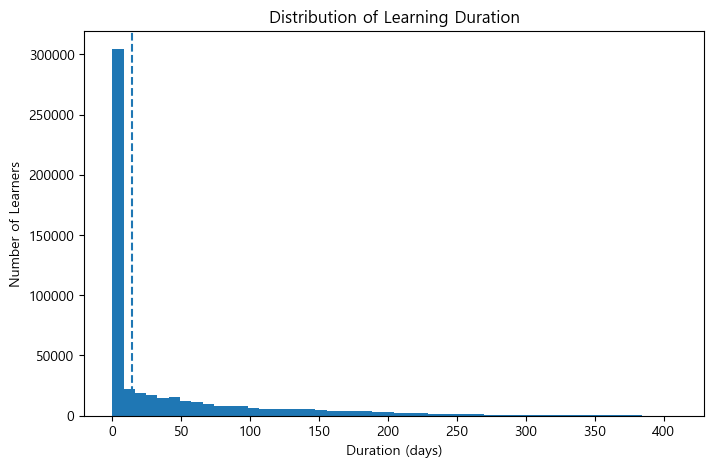

In [54]:
plt.figure(figsize=(8, 5))
plt.hist(df["duration"].dropna(), bins=50)
plt.axvline(14, linestyle="--")
plt.title("Distribution of Learning Duration")
plt.xlabel("Duration (days)")
plt.ylabel("Number of Learners")
plt.show()

duration 분포를 시각화한 결과,  
학습 지속 기간이 짧은 구간에 관측치가 밀집되어 있는지 여부를 확인할 수 있다.

또한 14일 기준선을 함께 표시함으로써,  
초기 이탈 구간이 전체 분포에서 어느 위치에 해당하는지 직관적으로 파악할 수 있다.

## 8.3 Duration 구간화해서 보기

이 파트가 들어가면 훨씬 깊어진다.
단순히 “14일 이하 몇 명”이 아니라,
시간이 지나면서 얼마나 줄어드는지 볼 수 있다.

In [55]:
df["duration_bin"] = pd.cut(
    df["duration"],
    bins=[-1, 0, 3, 7, 14, 30, 60, np.inf],
    labels=["0일", "1-3일", "4-7일", "8-14일", "15-30일", "31-60일", "61일+"]
)

duration_bin_table = (
    df["duration_bin"]
    .value_counts(dropna=False)
    .sort_index()
    .reset_index()
)

duration_bin_table.columns = ["duration_bin", "count"]
duration_bin_table["ratio"] = duration_bin_table["count"] / duration_bin_table["count"].sum()
duration_bin_table

,duration_bin,count,ratio
0,0일,236090,0.442122
1,1-3일,48302,0.090454
2,4-7일,16578,0.031045
3,8-14일,20646,0.038663
4,15-30일,37237,0.069733
5,31-60일,51013,0.095531
6,61일+,124127,0.232451


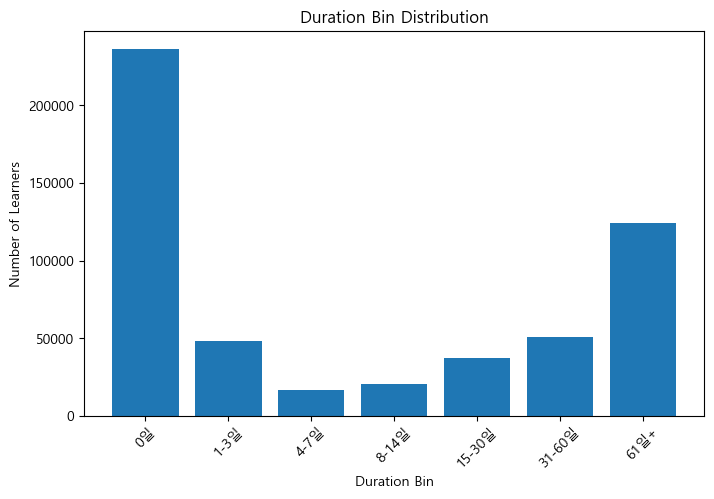

In [56]:
plt.figure(figsize=(8, 5))
plt.bar(duration_bin_table["duration_bin"].astype(str), duration_bin_table["count"])
plt.title("Duration Bin Distribution")
plt.xlabel("Duration Bin")
plt.ylabel("Number of Learners")
plt.xticks(rotation=45)
plt.show()

## 8.5 Activity Pattern by Early Drop

early drop 집단과 non-early drop 집단이  
어떤 활동 수준 차이를 보이는지 탐색적으로 확인한다.

다만 활동 변수들은 학습 기간의 누적 효과를 일부 반영하고 있으므로,  
본 비교는 초기 이탈의 원인을 직접 설명하기 위한 분석이 아니라  
초기 이탈 집단이 결과적으로 어떤 활동 패턴을 보였는지를 확인하는 보조적 분석으로 해석한다.

In [57]:
activity_vars = ["nevents", "ndays_act", "nplay_video", "nchapters", "nforum_posts"]

df.groupby("early_drop")[activity_vars].median()

,nevents,ndays_act,nplay_video,nchapters,nforum_posts
early_drop,,,,,
0,105.0,4.0,33.0,3.0,0.0
1,2.0,1.0,0.0,0.0,0.0


In [58]:
df.groupby("early_drop")[activity_vars].mean()

,nevents,ndays_act,nplay_video,nchapters,nforum_posts
early_drop,,,,,
0,839.495769,10.392914,165.245502,5.241293,0.050698
1,37.721834,1.127676,6.310464,0.912159,0.004132


<Figure size 600x400 with 0 Axes>

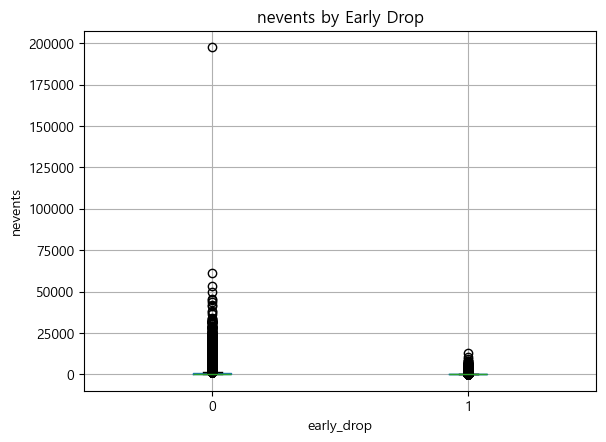

<Figure size 600x400 with 0 Axes>

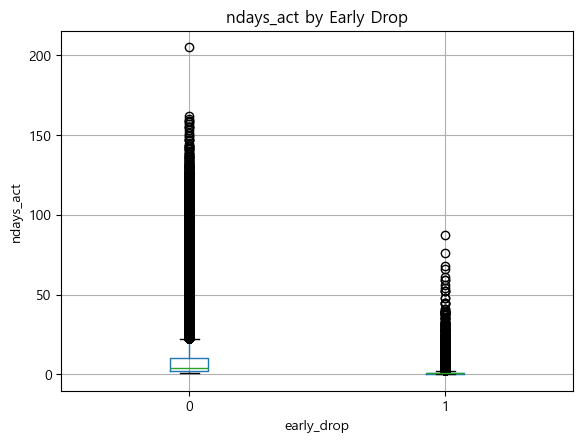

<Figure size 600x400 with 0 Axes>

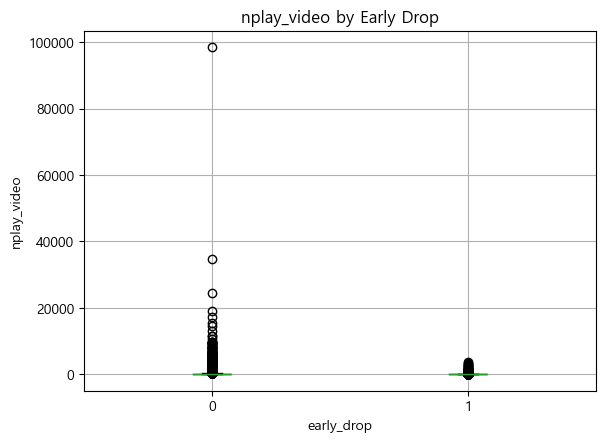

<Figure size 600x400 with 0 Axes>

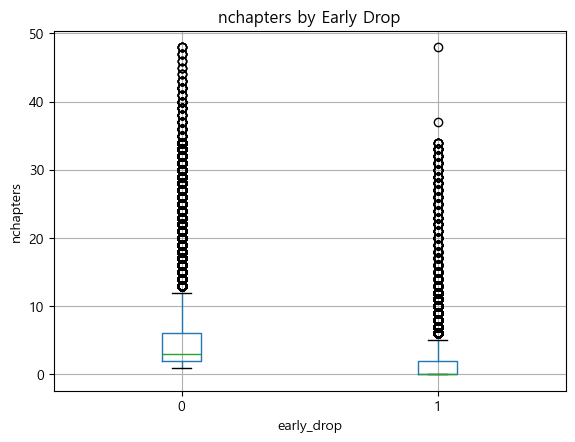

<Figure size 600x400 with 0 Axes>

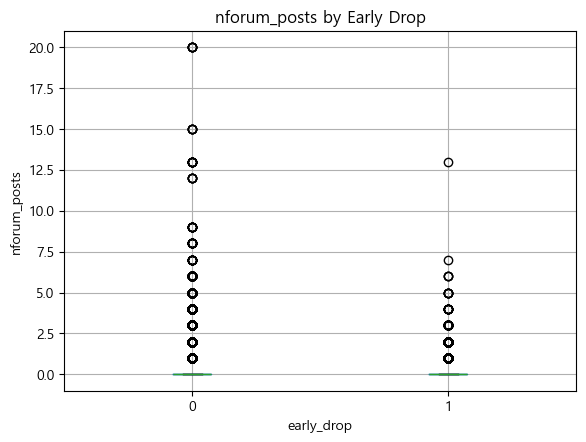

In [59]:
for var in activity_vars:
    plt.figure(figsize=(6, 4))
    df.boxplot(column=var, by="early_drop")
    plt.title(f"{var} by Early Drop")
    plt.suptitle("")
    plt.xlabel("early_drop")
    plt.ylabel(var)
    plt.show()

## 8.6 Early Drop과 Funnel Stage의 교차 분포

In [60]:
pd.crosstab(df["early_drop"], df["viewed"], normalize="index")

viewed,0,1
early_drop,,
0,0.092251,0.907749
1,0.587782,0.412218


In [61]:
pd.crosstab(df["early_drop"], df["explored"], normalize="index")

explored,0,1
early_drop,,
0,0.829252,0.170748
1,0.995893,0.004107


In [62]:
pd.crosstab(df["early_drop"], df["sufficient"], normalize="index")

sufficient,0,1
early_drop,,
0,0.945375,0.054625
1,0.999164,0.000836


### Interpretation

Early Drop 분석 결과,  
초기 이탈 집단과 비이탈 집단 간에는 매우 큰 활동 수준 차이가 존재하는 것으로 나타났다.

중앙값 기준으로 살펴보면,  
early drop 집단은 대부분의 활동 변수에서 거의 0에 가까운 값을 보였으며,  
특히 nchapters와 nplay_video는 사실상 학습이 이루어지지 않은 수준으로 나타났다.

반면 non-early drop 집단은  
nevents, ndays_act, nplay_video, nchapters 전반에서  
의미 있는 수준의 활동을 보이며,  
학습이 일정 수준 이상 지속된 것으로 확인된다.

평균값 기준에서도 동일한 패턴이 나타났으며,  
특히 nevents와 nplay_video에서 큰 격차가 확인되었다.  
이는 초기 이탈 집단이 단순히 학습을 중단한 것이 아니라,  
실질적인 학습 활동 자체가 거의 발생하지 않은 상태에서 이탈했음을 의미한다.

또한 Funnel 단계와의 교차 분포를 확인한 결과,  
early drop 집단은 viewed 비율이 약 41% 수준에 그치며,  
explored와 sufficient 단계로의 전환은 거의 발생하지 않는 것으로 나타났다.

특히 explored 비율이 약 0.4%, sufficient 비율이 0.08% 수준에 불과하다는 점은,  
초기 이탈이 발생한 학습자는 사실상 학습 단계로 진입하지 못한 상태에서  
이탈이 발생한다는 것을 보여준다.

반면 non-early drop 집단은 viewed 비율이 약 90% 이상이며,  
explored와 sufficient 단계로의 전환도 일정 수준 이상 유지되는 것으로 나타났다.

종합적으로 볼 때,  
초기 이탈은 학습 과정 중간에서 발생하는 문제가 아니라,  
학습이 본격적으로 시작되기 이전 단계에서 발생하는 구조적 문제로 해석할 수 있다.

즉, 학습자의 이탈은 단순히 참여도가 낮아서 발생하는 것이 아니라,  
초기 진입 자체가 이루어지지 않는 상태에서 빠르게 이탈하는 패턴을 보인다.

따라서 본 분석은  
학습자의 이탈을 Stage(어디서)와 Duration(언제)의 두 축으로 분리하여 해석할 필요성을 뒷받침하며,  
특히 초기 온보딩 구간에서의 경험 설계가  
전체 학습 지속률을 결정하는 핵심 요인임을 시사한다.

## 8.7 Early Drop의 월별, 강좌별 이탈률 분석

- 일별 이탈률을 좀 더 구체적으로 확인하기 위해, 일별 이탈률을 계산해 시각화하였다.

In [63]:
df_proportion = df.value_counts('duration').reset_index().sort_values('duration')
df_proportion['proportion'] = df_proportion['count'] / len(df)
df_proportion['fail_rate'] = 1 - df_proportion['proportion'].cumsum()

df_proportion['duration'] = df_proportion['duration'] + 1
start_point = pd.DataFrame({'duration':[0], 'fail_rate':[1.0]})
df_plot = pd.concat([start_point, df_proportion]).sort_values('duration').reset_index(drop = True)
df_plot.head(17)

,duration,fail_rate,count,proportion
0,0,1.000000,NaN,NaN
1,1,0.557878,236090.0,0.442122
2,2,0.491342,35530.0,0.066536
3,3,0.477400,7445.0,0.013942
4,4,0.467424,5327.0,0.009976
5,5,0.458978,4510.0,0.008446
6,6,0.451379,4058.0,0.007599
7,7,0.443822,4035.0,0.007556
8,8,0.436378,3975.0,0.007444
9,9,0.429966,3424.0,0.006412


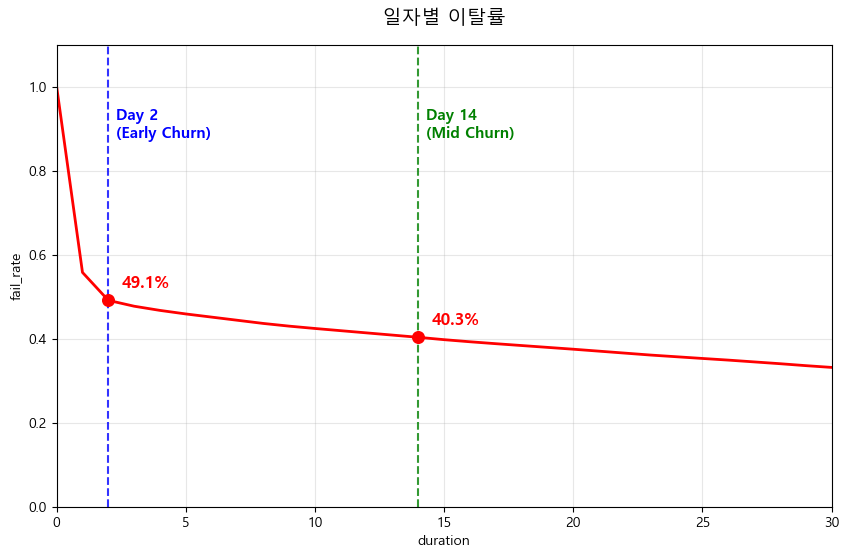

In [64]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=df_plot, x='duration', y='fail_rate', color='red', linewidth=2)

plt.axvline(x=2, color='blue', linestyle='--', linewidth=1.5, alpha=0.8)
plt.axvline(x=14, color='green', linestyle='--', linewidth=1.5, alpha=0.8)

plt.text(2.3, 0.95, 'Day 2\n(Early Churn)', color='blue', fontsize=11, fontweight='bold', va='top')
plt.text(14.3, 0.95, 'Day 14\n(Mid Churn)', color='green', fontsize=11, fontweight='bold', va='top')

val_day2 = df_plot.loc[df_plot['duration'] == 2, 'fail_rate'].values[0]
val_day14 = df_plot.loc[df_plot['duration'] == 14, 'fail_rate'].values[0]

plt.scatter([2, 14], [val_day2, val_day14], color='red', s=70, zorder=5)

plt.text(2.5, val_day2 + 0.03, f'{val_day2*100:.1f}%', color='red', fontsize=12, fontweight='bold')
plt.text(14.5, val_day14 + 0.03, f'{val_day14*100:.1f}%', color='red', fontsize=12, fontweight='bold')
    
plt.xlim(0, 30)
plt.ylim(0, 1.1) 
plt.title('일자별 이탈률', fontsize=14, pad=15)
plt.grid(True, alpha=0.3)

plt.show()

- 일자별 이탈률 표와 시각화 그래프를 통해, 초기 2일에 전체 50% 이상의 유저가 이탈을 하고 14일에 60% 가량의 유저가 이탈을 진행한다.

- 2일 이내 이탈자는 단순 호기심에 의한 '허수 트래픽'일 가능성이 높다. 비즈니스 관점에서 실질적으로 리텐션(잔존율)을 개선하기 위해서는 **'최소 2주간 강의를 탐색하며 적응을 시도하다 포기한 유저'**를 붙잡는 것이 훨씬 효과적이라 판단했다. 이에 따라 본 분석에서는 '초기 이탈'의 기준을 14일로 정의하고 핵심 타겟 방어 전략을 도출했다.

- 따라서, 14일 이내에 이탈한 유저를 메인으로, 2일 이내 이탈 유저를 보조적인 지표로 활용해 분석을 진행하였다.

In [65]:
df["early_drop_14"] = (df["duration"] <= 14).astype(int)
df["early_drop_2"] = (df["duration"] <= 2).astype(int)

df['start_time_DI'] = pd.to_datetime(df['start_time_DI'])
df['cohort_month'] = df['start_time_DI'].dt.to_period('M')

df_cohort_period = df.groupby('cohort_month').agg(
    total_users = ('start_time_DI', 'count'),
    drop_2_count = ('early_drop_2', 'sum'),
    drop_14_count = ('early_drop_14', 'sum')
).reset_index()

df_cohort_period['drop_2_rate'] = df_cohort_period['drop_2_count'] / df_cohort_period['total_users']
df_cohort_period['drop_14_rate'] = df_cohort_period['drop_14_count'] / df_cohort_period['total_users']
df_cohort_period

,cohort_month,total_users,drop_2_count,drop_14_count,drop_2_rate,drop_14_rate
0,2012-07,16261,8926,9044,0.548921,0.556177
1,2012-08,64322,35819,36671,0.556870,0.570116
2,2012-09,51621,25594,28916,0.495806,0.560160
3,2012-10,51649,27917,33752,0.540514,0.653488
4,2012-11,16854,10194,11460,0.604842,0.679957
5,2012-12,33072,16651,17433,0.503477,0.527123
6,2013-01,58255,21608,22567,0.370921,0.387383
7,2013-02,66292,26167,32965,0.394723,0.497270
8,2013-03,58049,29927,38436,0.515547,0.662130
9,2013-04,30531,18330,21235,0.600373,0.695523


In [66]:
print(df['start_time_DI'].max())
print(df['last_event_DI'].max())

2013-09-07 00:00:00
2013-09-07


- 9월의 초기 이탈률이 100%임을 확인해 현재 마지막 가입일과 활동일을 확인했을 때, 2013-09-07로 이 시점이 데이터 집계 시점임을 추측할 수 있다.

- 따라서, 이 일자의 2주 전의 데이터는 초기 이탈을 정확하게 분석할 수 없는 데이터라 판단하고 제거 후 분석을 진행하였다.

In [67]:
cutoff_date = df['start_time_DI'].max() - pd.Timedelta(days=14)

print(f"데이터의 마지막 가입일: {df['start_time_DI'].max()}")
print(f"관찰 기준일 (Cut-off): {cutoff_date}")

df_valid = df[df['start_time_DI'] <= cutoff_date].copy()

print(f"제거 전 원본 데이터 수: {len(df):,}명")
print(f"제거 후 분석용 데이터 수: {len(df_valid):,}명")

df = df_valid

데이터의 마지막 가입일: 2013-09-07 00:00:00
관찰 기준일 (Cut-off): 2013-08-24 00:00:00
제거 전 원본 데이터 수: 533,993명
제거 후 분석용 데이터 수: 526,046명


- 연-월별 이탈률

In [68]:
df_cohort_period = df.groupby('cohort_month').agg(
    total_users = ('start_time_DI', 'count'),
    drop_2_count = ('early_drop_2', 'sum'),
    drop_14_count = ('early_drop_14', 'sum')
).reset_index()

df_cohort_period['drop_2_rate'] = df_cohort_period['drop_2_count'] / df_cohort_period['total_users']
df_cohort_period['drop_14_rate'] = df_cohort_period['drop_14_count'] / df_cohort_period['total_users']
df_cohort_period

,cohort_month,total_users,drop_2_count,drop_14_count,drop_2_rate,drop_14_rate
0,2012-07,16261,8926,9044,0.548921,0.556177
1,2012-08,64322,35819,36671,0.556870,0.570116
2,2012-09,51621,25594,28916,0.495806,0.560160
3,2012-10,51649,27917,33752,0.540514,0.653488
4,2012-11,16854,10194,11460,0.604842,0.679957
5,2012-12,33072,16651,17433,0.503477,0.527123
6,2013-01,58255,21608,22567,0.370921,0.387383
7,2013-02,66292,26167,32965,0.394723,0.497270
8,2013-03,58049,29927,38436,0.515547,0.662130
9,2013-04,30531,18330,21235,0.600373,0.695523


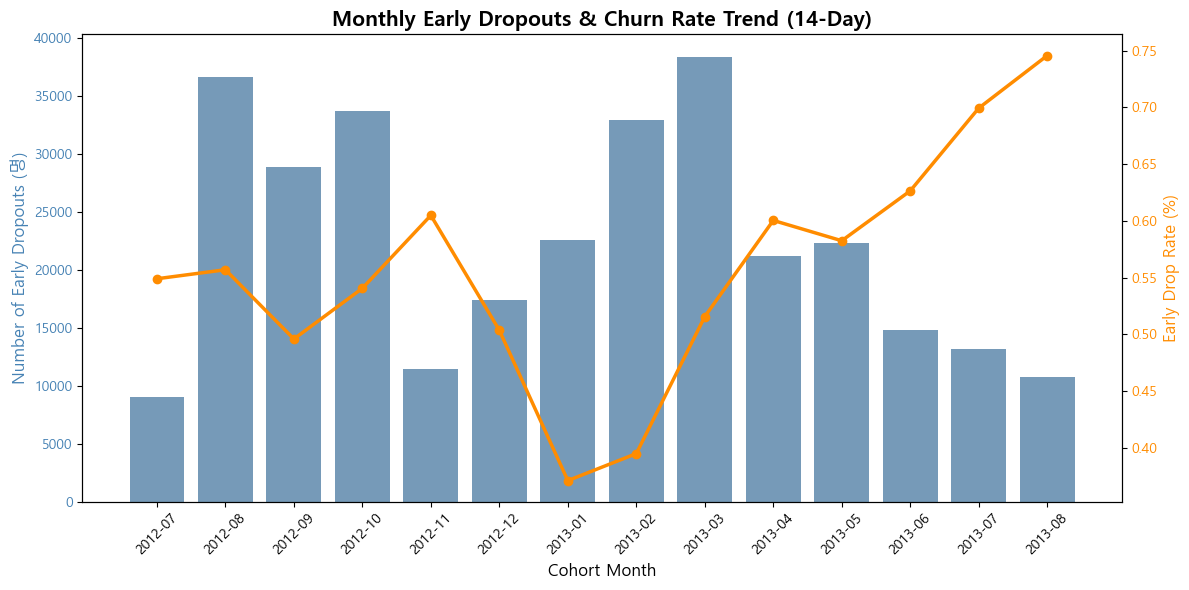

In [69]:
df_cohort_period['cohort_month_str'] = df_cohort_period['cohort_month'].astype(str)

fig, ax1 = plt.subplots(figsize=(12, 6))

sns.barplot(data=df_cohort_period, x='cohort_month_str', y='drop_14_count', color='steelblue', ax=ax1, alpha=0.8)
ax1.set_xlabel('Cohort Month', fontsize=12)
ax1.set_ylabel('Number of Early Dropouts (명)', color='steelblue', fontsize=12)
ax1.tick_params(axis='y', labelcolor='steelblue')
ax1.tick_params(axis='x', rotation=45)

ax2 = ax1.twinx() 

x_positions = range(len(df_cohort_period)) 
ax2.plot(x_positions, df_cohort_period['drop_2_rate'], color='darkorange', marker='o', linewidth=2.5)

ax2.set_ylabel('Early Drop Rate (%)', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Monthly Early Dropouts & Churn Rate Trend (14-Day)', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

- 강좌별 이탈률

In [70]:
course_korean_map = {

    # 🏛️ HarvardX 강좌

    'HarvardX/PH207x/2012_Fall': '임상 및 공중 보건 연구의 정량적 방법 (12 가을, Harvard)',

    'HarvardX/CB22x/2013_Spring': '고대 그리스 영웅 (13 봄, Harvard)',

    'HarvardX/ER22x/2013_Spring': '정의란 무엇인가 (13 봄, Harvard )',

    'HarvardX/PH278x/2013_Spring': '인류 건강과 환경 변화 (13 봄, Harvard)',

    'HarvardX/CS50x/2012': '컴퓨터 과학 개론 I (CS50) (12년, Harvard)',

    # 🔬 MITx 강좌

    'MITx/6.002x/2012_Fall': '회로 및 전자공학 (12 가을, MIT)',

    'MITx/6.002x/2013_Spring': '회로 및 전자공학 (13 봄, MIT)',

    'MITx/6.00x/2012_Fall': '컴퓨터 과학 및 프로그래밍 개론 (12 가을, MIT)',

    'MITx/6.00x/2013_Spring': '컴퓨터 과학 및 프로그래밍 개론 (13 봄, MIT)',

    'MITx/3.091x/2012_Fall': '고체 화학 개론 (12 가을, MIT)',

    'MITx/3.091x/2013_Spring': '고체 화학 개론 (13 봄, MIT)',

    'MITx/7.00x/2013_Spring': '생물학 개론: 생명의 비밀 (13 봄, MIT)',

    'MITx/8.02x/2013_Spring': '전자기학 (13 봄, MIT)',

    'MITx/2.01x/2013_Spring': '구조 역학 기초 (13 봄, MIT)',

    'MITx/14.73x/2013_Spring': '글로벌 빈곤의 과제 (13 봄, MIT)',

    'MITx/8.MReV/2013_Summer': '역학 리뷰 (Mechanics ReView) (13 여름, MIT)'

}

df['course_name_kr'] = df['course_id'].map(course_korean_map)

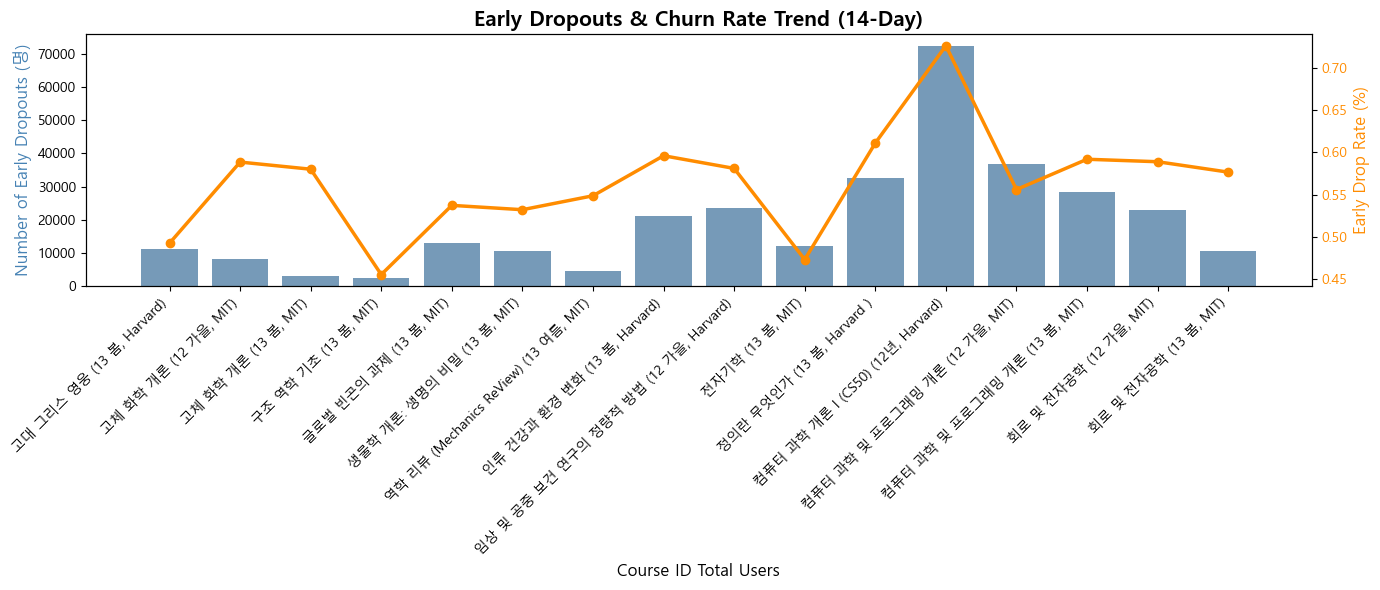

In [71]:
df_cohort_course = df.groupby('course_name_kr').agg(
    total_users=('userid_DI', 'count'),
    drop_14_count=('early_drop_14', 'sum'),      
    drop_14_rate=('early_drop_14', 'mean')       
).reset_index()

top_courses = df_cohort_course.sort_values(by='total_users', ascending=False).copy()

top_courses = top_courses.sort_values(by = 'course_name_kr').reset_index(drop = True)

fig, ax1 = plt.subplots(figsize=(14, 6))

# 이탈 유저 수
sns.barplot(data=top_courses, x='course_name_kr', y='drop_14_count', color='steelblue', ax=ax1, alpha=0.8)
ax1.set_xlabel('Course ID Total Users', fontsize=12)
ax1.set_ylabel('Number of Early Dropouts (명)', color='steelblue', fontsize=12)
ax1.set_xticks(range(len(top_courses))) # 경고 메시지 방지용
ax1.set_xticklabels(top_courses['course_name_kr'], rotation=45, ha='right')

# 이탈률
ax2 = ax1.twinx() 
x_positions = range(len(top_courses))
ax2.plot(x_positions, top_courses['drop_14_rate'], color='darkorange', marker='o', linewidth=2.5)

ax2.set_ylabel('Early Drop Rate (%)', color='darkorange', fontsize=12)
ax2.tick_params(axis='y', labelcolor='darkorange')

plt.title('Early Dropouts & Churn Rate Trend (14-Day)', fontsize=15, fontweight='bold')
fig.tight_layout()
plt.show()

- 전반적인 경향성은 뚜렷하지 않았으나, 2013년 1월과 2월의 초기 이탈률이 각각 38.7%, 49.7%로 전체 평균 대비 이례적으로 낮게 나타났다. 해당 시기 개설 강좌들이 전자기학, 구조역학기초 등 진입 장벽이 높은 심화 과목임을 고려할 때, 강의 난이도가 초기 이탈의 주원인이 아님을 유추할 수 있다. 이는 연초의 강력한 자기계발 동기(신년 효과)와 미국 대학 정규 봄 학기(Spring Semester) 개강 시즌이 맞물려 만들어낸 긍정적 시너지로 추정된다.

- 강의별 이탈률을 보았을 때, 앞서 언급한 1,2월 개설 강좌를 제외하면 전반적으로 수강 인원에 관련 없이 비슷한 이탈률을 보인다. 유일하게 다른 패턴을 보인 CS50x의 경우 강좌가 유튜브에 개설이 되어 있어, 플랫폼을 통해 접속하기 보다는 유튜브로 접속을 한 인원들 역시 존재할 것으로 추측해 이탈률이 다른 강좌보다 높을 것으로 예상된다.

## 8.8 Early Drop의 강좌 개설 이후 진입 별 이탈률 분석

In [72]:
# 강좌별 개설 날짜
course_start_df = df.groupby(['course_id'])['start_time_DI'].min().sort_values().reset_index().rename(columns = {'start_time_DI':'course_start'})
course_start_df

,course_id,course_start
0,HarvardX/PH207x/2012_Fall,2012-07-23
1,MITx/3.091x/2012_Fall,2012-07-23
2,MITx/6.002x/2012_Fall,2012-07-23
3,MITx/6.00x/2012_Fall,2012-07-23
4,HarvardX/CS50x/2012,2012-07-24
5,HarvardX/CB22x/2013_Spring,2012-12-19
6,HarvardX/ER22x/2013_Spring,2012-12-19
7,HarvardX/PH278x/2013_Spring,2012-12-19
8,MITx/14.73x/2013_Spring,2012-12-19
9,MITx/3.091x/2013_Spring,2012-12-19


In [73]:
df_tmp = df.merge(course_start_df, on='course_id', how='left')

df_tmp['days_after_start'] = (pd.to_datetime(df_tmp['start_time_DI']) - df_tmp['course_start']).dt.days
df_tmp['months_after_start'] = (df_tmp['days_after_start'] // 30) + 1

df_tmp['months_after_start'].value_counts()

df = df_tmp

In [74]:
df[df['course_id'].isin(course_start_df.loc[course_start_df['course_start'].dt.strftime('%Y-%m') == '2012-07', 'course_id'])].groupby('months_after_start').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
)

,user_count,drop_rate_14
months_after_start,,
1,63982,0.571036
2,52738,0.551045
3,56032,0.633584
4,22854,0.668636
5,15375,0.706537
6,4977,0.535463
7,4373,0.516122
8,10270,0.761344
9,4749,0.790272


In [75]:
df[df['course_id'].isin(course_start_df.loc[course_start_df['course_start'].dt.strftime('%Y-%m') == '2012-12', 'course_id'])].groupby('months_after_start').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
)

,user_count,drop_rate_14
months_after_start,,
1,46482,0.467364
2,45492,0.406555
3,40328,0.595740
4,25016,0.694356
5,16741,0.696255
6,14247,0.745771
7,5126,0.734101
8,11625,0.847570
9,3027,0.950116


In [76]:
df[df['course_id'].isin(course_start_df.loc[course_start_df['course_start'].dt.strftime('%Y-%m') == '2013-01', 'course_id'])].groupby('months_after_start').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
)

,user_count,drop_rate_14
months_after_start,,
1,21387,0.295881
2,13149,0.633204
3,5172,0.734532
4,2921,0.762068
5,1281,0.718970
6,91,0.736264
7,534,0.786517
8,329,0.917933


In [77]:
df[df['course_id'].isin(course_start_df.loc[course_start_df['course_start'].dt.strftime('%Y-%m') == '2013-02', 'course_id'])].groupby('months_after_start').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
)

,user_count,drop_rate_14
months_after_start,,
1,1675,0.355821
2,2742,0.427790
3,902,0.668514
4,215,0.683721
5,2,1.000000
6,8,0.625000


In [78]:
df[df['course_id'].isin(course_start_df.loc[course_start_df['course_start'].dt.strftime('%Y-%m') == '2013-04', 'course_id'])].groupby('months_after_start').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
)

,user_count,drop_rate_14
months_after_start,,
1,3292,0.358445
2,2787,0.575170
3,1349,0.725723
4,985,0.851777
5,34,1.000000


In [79]:
df_enter_plot = df.groupby('months_after_start').agg(
    user_count=('userid_DI', 'count'),
    drop_rate_14=('early_drop_14', 'mean')
).reset_index()
df_enter_plot

,months_after_start,user_count,drop_rate_14
0,1,136818,0.485053
1,2,116908,0.501745
2,3,103783,0.625411
3,4,51991,0.689792
4,5,33433,0.702180
5,6,19323,0.691508
6,7,10033,0.641882
7,8,22224,0.808765
8,9,7776,0.852495
9,10,5423,0.798635


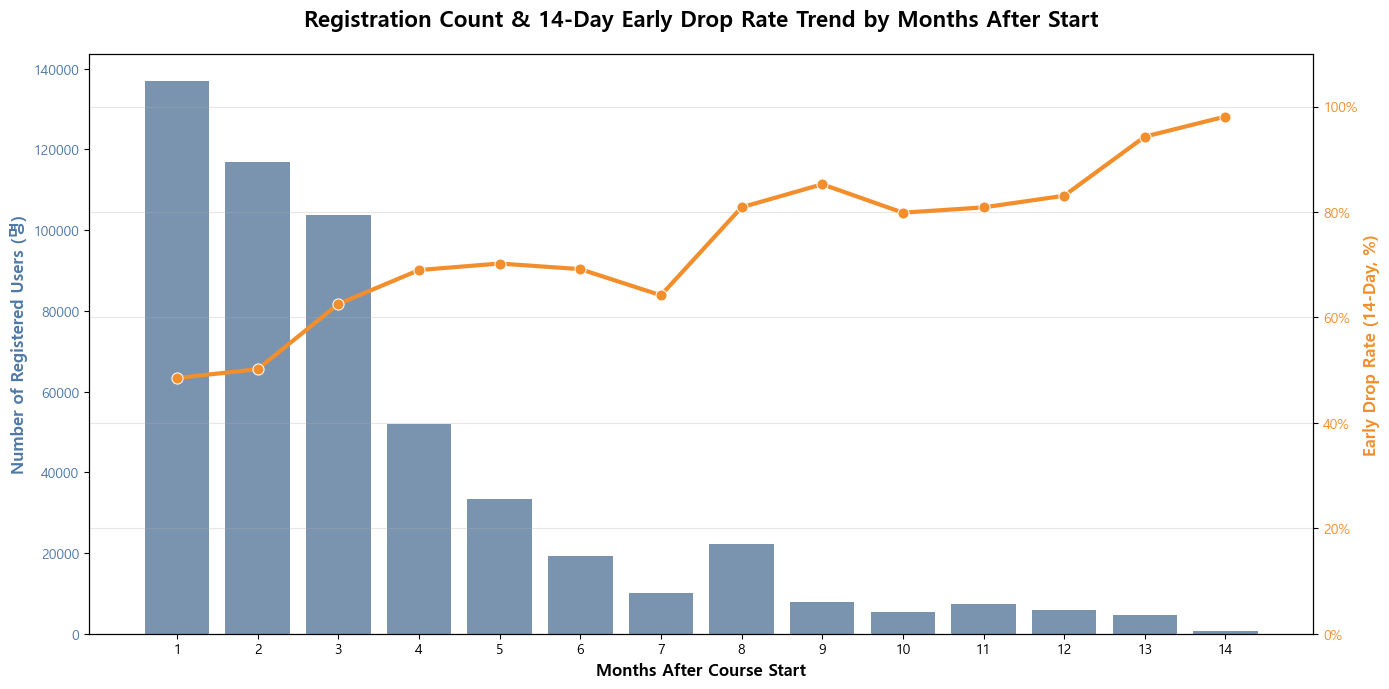

In [80]:
df_enter_plot['drop_rate_14_pct'] = df_enter_plot['drop_rate_14'] * 100

# 막대그래프(이탈 유저 수)
fig, ax1 = plt.subplots(figsize=(14, 7))

bar_color = '#4e79a7'

sns.barplot(
    data=df_enter_plot,
    x='months_after_start',
    y='user_count',
    color=bar_color,
    alpha=0.8,
    ax=ax1
)

ax1.set_ylabel('Number of Registered Users (명)', color=bar_color, fontsize=12, fontweight='bold')
ax1.tick_params(axis='y', labelcolor=bar_color)
ax1.set_xlabel('Months After Course Start', fontsize=12, fontweight='bold')


# 꺾은선 그래프(초기 이탈률)
ax2 = ax1.twinx()

line_color = '#f28e2b'

sns.lineplot(
    data=df_enter_plot,
    x=range(len(df_enter_plot)),
    y='drop_rate_14_pct',
    color=line_color,
    linewidth=3,
    marker='o', 
    markersize=8,
    ax=ax2
)

ax2.set_ylabel('Early Drop Rate (14-Day, %)', color=line_color, fontsize=12, fontweight='bold')
ax2.tick_params(axis='y', labelcolor=line_color)
ax2.yaxis.set_major_formatter(PercentFormatter()) 
ax2.set_ylim(0, 110) 


plt.title('Registration Count & 14-Day Early Drop Rate Trend by Months After Start', fontsize=16, fontweight='bold', pad=20)
plt.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

- 개강 이후 시점별 초기 이탈률을 시각화하여 확인한 결과, 가입 시점이 늦어질수록 이탈률이 뚜렷하게 급증하는 우상향 트렌드가 나타났다. 전체 가입자의 대다수가 개강 후 3개월 이내에 집중되어 있으며, 개강 3개월 차를 기점으로 신규 유입 규모는 급감하는 모습이 확인되었다. 

- 또한, 이탈률은 초기 가입일 이후 점진적으로 증가하는 패턴을 보인다. 이는 복잡한 통계적 검정 없이도, 개강 후 3개월 이내에 진입한 초기 진입자와 3개월 초과 지점에 진입한 후발 진입자 집단을 명확히 분리하여 완전히 다른 14일 초기 온보딩 및 리텐션 전략을 적용해야 함을 시사한다.

## 8.9 초기 이탈 관련 인구 통계 차이 분석

In [81]:
# 학력 검정
ct = pd.crosstab(df['early_drop_14'], df['LoE_DI'])
display(ct)

chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')

LoE_DI,Bachelor's,Doctorate,Less than Secondary,Master's,Secondary,unknown
early_drop_14,,,,,,
0,67444,4751,4386,41030,51778,42988
1,113207,6762,6562,57949,85284,43905


검정 통계량 및 p-value : 4117.6748, 0.0000


array([[ 72933.00857149,   4648.06576041,   4419.96212499,
         39960.12341696,  55335.11589101,  35080.72423514],
       [107717.99142851,   6864.93423959,   6528.03787501,
         59018.87658304,  81726.88410899,  51812.27576486]])

검정의 효과크기 : 0.0885


In [82]:
df_tmp = df[df['gender'] != 'o']

ct = pd.crosstab(df_tmp['early_drop_14'], df_tmp['gender'])
display(ct)

chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')

gender,f,m,unknown
early_drop_14,,,
0,45758,128644,37975
1,73488,206110,34064


검정 통계량 및 p-value : 5281.4313, 0.0000


array([[ 48143.02312566, 135149.77075464,  29084.2061197 ],
       [ 71102.97687434, 199604.22924536,  42954.7938803 ]])

검정의 효과크기 : 0.1002


In [83]:
language_map = {
    # 🇺🇸 영어권 (English)
    'United States': 'English', 'Australia': 'English', 'Canada': 'English', 
    'United Kingdom': 'English', 'India': 'English', 'Nigeria': 'English', 
    'Philippines': 'English', 'Pakistan': 'English', 

    # 🌐 비영어권 (Non-English)
    'France': 'Non-English', 'Russian Federation': 'Non-English', 'Mexico': 'Non-English', 
    'Japan': 'Non-English', 'Colombia': 'Non-English', 'Germany': 'Non-English', 
    'Indonesia': 'Non-English', 'Bangladesh': 'Non-English', 'China': 'Non-English', 
    'Ukraine': 'Non-English', 'Spain': 'Non-English', 'Brazil': 'Non-English', 
    'Poland': 'Non-English', 'Egypt': 'Non-English', 'Greece': 'Non-English', 
    'Portugal': 'Non-English', 'Morocco': 'Non-English',
    'Other North & Central Amer., Caribbean': 'Non-English', 'Other South Asia': 'Non-English', 
    'Other Europe': 'Non-English', 'Other Africa': 'Non-English', 
    'Other Middle East/Central Asia': 'Non-English', 'Other East Asia': 'Non-English', 
    'Other South America': 'Non-English', 'Other Oceania': 'Non-English',

    # ❓ 알 수 없음
    'Unknown/Other': 'Unknown'
}

In [84]:
# English, Non-English에 대한 큰 차이가 보이지 않아 검정까진 진행하지 않음.
df['language_group'] = df['final_cc_cname_DI'].map(language_map)
df.groupby('language_group')['early_drop'].mean()

language_group
English        0.570533
Non-English    0.537368
Unknown        0.981509
Name: early_drop, dtype: float64

In [85]:
economy_map = {
    # 🏙️ 선진국 (Developed)
    'United States': 'Developed', 'France': 'Developed', 'Australia': 'Developed', 
    'Canada': 'Developed', 'Japan': 'Developed', 'Germany': 'Developed', 
    'United Kingdom': 'Developed', 'Spain': 'Developed', 'Greece': 'Developed', 
    'Portugal': 'Developed', 'Poland': 'Developed', 'Other Europe': 'Developed', 
    'Other Oceania': 'Developed',

    # 🏭 개발도상국 (Developing)
    'Russian Federation': 'Developing', 'India': 'Developing', 'Mexico': 'Developing', 
    'Colombia': 'Developing', 'Indonesia': 'Developing', 'China': 'Developing', 
    'Ukraine': 'Developing', 'Brazil': 'Developing', 'Egypt': 'Developing', 
    'Philippines': 'Developing', 'Morocco': 'Developing', 'Bangladesh': 'Developing', 
    'Pakistan': 'Developing', 'Nigeria': 'Developing', 
    'Other South America': 'Developing', 'Other North & Central Amer., Caribbean': 'Developing', 
    'Other East Asia': 'Developing', 'Other Middle East/Central Asia': 'Developing',
    'Other South Asia': 'Developing', 'Other Africa': 'Developing',

    # ❓ 알 수 없음
    'Unknown/Other': 'Unknown'
}

In [86]:
# 두 그룹에 대한 큰 차이가 보이지 않아 검정까진 진행하지 않음.
df['economy_group'] = df['final_cc_cname_DI'].map(economy_map)
df.groupby('economy_group')['early_drop'].mean()

economy_group
Developed     0.556233
Developing    0.558301
Unknown       0.981509
Name: early_drop, dtype: float64

In [87]:
continent_map = {
    # 🌎 북미 / 중미 (North America)
    'United States': 'North America',
    'Canada': 'North America',
    'Mexico': 'North America',
    'Other North & Central Amer., Caribbean': 'North America',

    # 🌎 남미 (South America)
    'Colombia': 'South America',
    'Brazil': 'South America',
    'Other South America': 'South America',

    # 🌍 유럽 (Europe)
    'France': 'Europe',
    'Russian Federation': 'Europe', 
    'Germany': 'Europe',
    'United Kingdom': 'Europe',
    'Ukraine': 'Europe',
    'Spain': 'Europe',
    'Poland': 'Europe',
    'Greece': 'Europe',
    'Portugal': 'Europe',
    'Other Europe': 'Europe',

    # 🌏 아시아 (Asia) - 중동 포함
    'India': 'Asia',
    'Japan': 'Asia',
    'Indonesia': 'Asia',
    'Bangladesh': 'Asia',
    'China': 'Asia',
    'Pakistan': 'Asia',
    'Philippines': 'Asia',
    'Other South Asia': 'Asia',
    'Other East Asia': 'Asia',
    'Other Middle East/Central Asia': 'Asia',

    # 🌍 아프리카 (Africa)
    'Nigeria': 'Africa',
    'Egypt': 'Africa',
    'Morocco': 'Africa',
    'Other Africa': 'Africa',

    # 🌊 오세아니아 (Oceania)
    'Australia': 'Oceania',
    'Other Oceania': 'Oceania',

    # ❓ 알 수 없음
    'Unknown/Other': 'Unknown'
}

In [88]:
# 그룹이 많기 때문에, 카이제곱 검정 진행
df['continent'] = df['final_cc_cname_DI'].map(continent_map)
df.groupby('continent')['early_drop'].mean()

continent
Africa           0.599886
Asia             0.563824
Europe           0.489596
North America    0.583412
Oceania          0.584212
South America    0.533936
Unknown          0.981509
Name: early_drop, dtype: float64

In [89]:
# Unknown 때문에 효과크기가 크게 나왔을 가능성이 높아, Unknown 빼고 재검정
ct = pd.crosstab(df['early_drop_14'], df['continent'])
display(ct)

chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')

continent,Africa,Asia,Europe,North America,Oceania,South America,Unknown
early_drop_14,,,,,,,
0,15466,59036,49475,71776,2365,13363,896
1,23188,76313,47458,100519,3323,15309,47559


검정 통계량 및 p-value : 35632.7364, 0.0000


array([[ 15605.51844896,  54643.53796626,  39134.10565046,
         69559.49710672,   2296.37783768,  11575.55298206,
         19562.41000787],
       [ 23048.48155104,  80705.46203374,  57798.89434954,
        102735.50289328,   3391.62216232,  17096.44701794,
         28892.58999213]])

검정의 효과크기 : 0.2603


In [90]:
df_tmp = df[df['continent'] != 'Unknown']

ct = pd.crosstab(df_tmp['early_drop_14'], df_tmp['continent'])
display(ct)

chi2_stat, p_val, ddof, expected = chi2_contingency(ct)
print(f'검정 통계량 및 p-value : {chi2_stat:.4f}, {p_val:.4f}')
display(expected)

cramers_v = association(ct.values, method = 'cramer')
print(f'검정의 효과크기 : {cramers_v:.4f}')

continent,Africa,Asia,Europe,North America,Oceania,South America
early_drop_14,,,,,,
0,15466,59036,49475,71776,2365,13363
1,23188,76313,47458,100519,3323,15309


검정 통계량 및 p-value : 2664.5961, 0.0000


array([[17116.2910817 , 59933.58725143, 42922.68441616, 76293.5626823 ,
         2518.69052809, 12696.18404032],
       [21537.7089183 , 75415.41274857, 54010.31558384, 96001.4373177 ,
         3169.30947191, 15975.81595968]])

검정의 효과크기 : 0.0747


- 유저의 인구 통계정보는 초기 이탈률에 크게 관여하지 않음.

- 단, Unknown의 경우 앞선 분석과 동일한 의미를 가져 상세하게 분석하지 않음.

### Interpretation

Early Drop의 시점 분석 결과, 강의 개설 이후의 시작시점에 대해서 3개월 이내에 진입하는 유저의 수가 많고, 이후 4개월차부터 급감하는 모습을 보인다.

또한, 이탈률은 초기 시점에 강의에 진입한 유저들의 이탈률이 가장 낮고, 이후 서서히 증가하는 패턴을 보인다.

종합적으로 볼 때, 3개월 이내에 진입한 초기 진입자와 이후에 진입한 후발 진입자 집단에 대해 다른 초기 14일 리텐션 전략을 적용해야 함을 시사한다.

한편, 유저의 인구 통계정보는 초기 이탈과 무관한 모습을 보인다.